In [2]:
import numpy as np
import pandas as pd

import os

import datetime, warnings
warnings.filterwarnings("ignore")

import kagglehub

### 1. Adquisición y Configuración de Datos

En esta etapa inicial, utilizamos la librería `kagglehub` para descargar la versión más reciente del dataset de vuelos de 2024. Este dataset es masivo, lo que requiere una gestión eficiente de la memoria y el almacenamiento.

**Dataset:** Flight Data 2024

**Fuente:** Kaggle (Hrishit Patil)

**Contenido:** Información detallada de vuelos en EE. UU., incluyendo tiempos programados, reales, aerolíneas y aeropuertos.

In [3]:
path = kagglehub.dataset_download("hrishitpatil/flight-data-2024")

print("Path to dataset files:", path)

data_path = os.path.join( path, 'flight_data_2024.csv')

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\hrishitpatil\flight-data-2024\versions\2


# **Creación Dataframe**

### 2. Definición de Herramientas de Inspección

Para gestionar la complejidad del dataset, definimos una función de utilidad llamada `ver_df`. Esta función actúa como un escaneo de salud inicial para cualquier DataFrame que carguemos.

**Objetivos de la Inspección:**

**Dimensiones:** Comprender el volumen de datos (filas y columnas).

**Consistencia Técnica:** Verificar tipos de datos y uso de memoria mediante `.info()`.

**Estadística Descriptiva:** Observar la distribución de las variables numéricas con `.describe()`.

**Integridad:** Identificar la presencia de valores nulos (NaN), lo cual es crítico para decidir estrategias de limpieza posteriores.

**Análisis de Clase:** Evaluar el balance de la variable objetivo (retrasos) para detectar posibles sesgos en los datos.

In [4]:
def ver_df(path, columna_buscar):
    df = pd.read_csv(path, encoding='utf-8', sep=',')

    print(f"cantidad de muestras: {df.shape[0]}")
    print(f"cantidad de columnas: {df.shape[1]}")
    #print(f'Demo del data frame: \n{df.head(15)}')
    print(f'info del data frame: \n{df.info()}')
    print(f'descripción del data frame: \n{df.describe()}')
    print(f'columnas con valores nulos: \n{df.isna().sum()}')
    print(f'cantidad de valores del data frame: \n{df[columna_buscar].value_counts()}')
    print(f"cantidad de muestras validas: \n {df.shape[0]-df[columna_buscar].isna().sum()}")
    return df

# EDA de los datos

### 3. Carga y Diagnóstico del Dataset de Vuelos

Ejecutamos la función de inspección sobre el archivo principal. En este paso, nos enfocamos específicamente en la columna `arr_delay` (retraso de llegada), ya que será la base para construir nuestra variable objetivo.

**Aspectos Clave del Diagnóstico:**

**Magnitud:** Confirmamos si el hardware actual puede manejar el volumen de registros reportado.

**Calidad de la Variable Objetivo:** Analizamos cuántos vuelos tienen información de retraso válida. Los valores nulos en esta columna representarían vuelos cancelados o desviados que requieren un tratamiento especial.

**Distribución Inicial:** Observamos el rango de los retrasos (en minutos) para identificar valores atípicos (outliers) extremos que podrían distorsionar el modelo.

In [5]:
df = ver_df(data_path, 'arr_delay')

cantidad de muestras: 7079081
cantidad de columnas: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 35 columns):
 #   Column               Dtype  
---  ------               -----  
 0   year                 int64  
 1   month                int64  
 2   day_of_month         int64  
 3   day_of_week          int64  
 4   fl_date              object 
 5   op_unique_carrier    object 
 6   op_carrier_fl_num    float64
 7   origin               object 
 8   origin_city_name     object 
 9   origin_state_nm      object 
 10  dest                 object 
 11  dest_city_name       object 
 12  dest_state_nm        object 
 13  crs_dep_time         int64  
 14  dep_time             float64
 15  dep_delay            float64
 16  taxi_out             float64
 17  wheels_off           float64
 18  wheels_on            float64
 19  taxi_in              float64
 20  crs_arr_time         int64  
 21  arr_time             float64
 22  arr_delay  

## Limpieza data set base

### 4. Limpieza de Datos e Ingeniería de Variables (Feature Engineering)

En esta etapa, realizamos una transformación profunda del dataset para pasar de datos administrativos a variables predictivas. La limpieza no solo consiste en borrar errores, sino en adaptar la información al contexto físico y temporal del problema.

**Acciones Principales:**

**Integridad y Unicidad:** Eliminación de registros duplicados para evitar el sobreajuste (overfitting) por repetición de datos.

**Normalización de Unidades:** Conversión de la distancia de millas a kilómetros (`distancia_km`) para estandarizar las magnitudes físicas.

**Tratamiento de Nulos Críticos:** Eliminación de registros con valores ausentes en hitos operativos (tiempos de rodaje, despegue y aterrizaje), ya que un vuelo sin estos datos no permite calcular el retraso real.

**Creación del Target:** Definición de la variable objetivo `retraso`. Siguiendo el estándar de la industria, cualquier vuelo con `arr_delay > 0` se etiqueta como 1 (Retrasado) y el resto como 0 (A tiempo).

**Nuevas Variables de Contexto:**

**Bloques Horarios:** Segmentación de la hora de salida en categorías humanas (Madrugada, Mañana, Tarde, Noche). Esto ayuda al modelo a capturar la congestión acumulada a lo largo del día.

**Indicador de Fin de Semana:** Creación de la variable `is_weekend` para capturar patrones de tráfico estacional y variaciones en la demanda de pasajeros.

In [6]:
def limpieza_dataset_base(df):
    
    df.drop_duplicates(inplace=True)
    
    df['distancia_km'] = df['distance'] * 1.60934
    
    columnas_con_nulos = ['op_carrier_fl_num', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'arr_time', 'arr_delay', 'actual_elapsed_time','actual_elapsed_time', 'air_time']
                          

    df.dropna(subset=columnas_con_nulos, inplace=True)
    
    
    df['retraso'] = np.where(df['arr_delay']>0, 1, 0)
    
    df['dep_hour'] = (df['dep_time']//100).astype(int)
    bins = [0, 6, 12, 18, 24]
    labels = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
    df['bloque_horario'] = pd.cut(df['dep_hour'], bins=bins, labels=labels, include_lowest=True)
    df['is_weekend'] = df['day_of_week'].isin([6, 7]).astype(int)

    total_filas = len(df)

    print(total_filas)
    
    return df

### 5. Ejecución del Proceso de Limpieza y Transformación

Aplicamos la función de limpieza al DataFrame original. Este paso consolida todos los cambios estructurales y genera nuestra variable target. Al finalizar esta celda, el dataset está listo para ser cruzado con otras fuentes de datos o para entrar directamente a la fase de preprocesamiento.

**Estado Final del Dataset:**

**Consistencia:** Se garantiza que cada fila representa un vuelo con datos operativos completos.

**Etiquetado:** Cada registro cuenta con su clasificación binaria (0 o 1).

**Enriquecimiento:** Se han incorporado las nuevas dimensiones temporales (`bloque_horario`, `is_weekend`) y métricas (`distancia_km`).

In [7]:
df = limpieza_dataset_base(df)

6965266


### 6. Eliminación de Variables Irrelevantes y Prevención de Data Leakage

En esta etapa, realizamos una limpieza selectiva de columnas que no deben estar presentes durante el entrenamiento del modelo por dos razones principales:

**Evitar el "Data Leakage":** Columnas como `weather_delay`, `nas_delay` o la propia `arr_delay` contienen información que solo se conoce después de que el vuelo ha aterrizado. Si las dejamos, el modelo "predeciría" el futuro usando información del futuro, arrojando resultados falsamente perfectos que fallarían en la vida real.

**Reducción de Ruido:** Eliminamos variables redundantes como `distance` (sustituida por `distancia_km`) o constantes como `cancelled` (ya filtramos los vuelos no realizados) para optimizar el uso de memoria y mejorar la velocidad de entrenamiento.

**Variables Eliminadas:**

- **Métricas de Retraso Específicas:** `carrier_delay`, `nas_delay`, etc.
- **Información Post-Vuelo:** `arr_delay`, `dep_delay`
- **Identificadores y Fechas Brutas:** `fl_date`, `cancellation_code`

> **Nota:** Se hace una copia del dataframe para futuras gráficas.

In [8]:
columnas_basura = ['cancellation_code', 'distance', 'fl_date', 'cancelled', 'arr_delay','dep_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
df_grap = df.copy()
df.drop(columns=columnas_basura, inplace=True)

## Exploración de los datos

### 7. Configuración de Herramientas de Visualización

Para validar nuestras hipótesis y entender el comportamiento del modelo, cargamos las librerías estándar de visualización de datos en Python.

**Matplotlib:** Proporciona la infraestructura base para la creación de gráficos estáticos, animados e interactivos.

**Seaborn:** Una capa superior basada en Matplotlib que permite generar gráficos estadísticos más atractivos e informativos con menos código (como matrices de confusión y gráficos de importancia de variables).

Estas herramientas nos permitirán transformar métricas abstractas (como la precisión o el recall) en información accionable para la toma de decisiones.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

### 8. Análisis de Retrasos por Aerolínea

En esta sección, realizamos un análisis agrupado para cuantificar el desempeño de cada aerolínea (`op_unique_carrier`). El objetivo es observar si existen diferencias significativas en la proporción de retrasos entre compañías.

**Metodología del Análisis:**

**Agrupamiento Operativo:** Agrupamos los datos por el código de la aerolínea para aislar su comportamiento.

**Frecuencia de Clases:** Calculamos la distribución de la variable `retraso` (0 vs 1) para cada transportista.

**Identificación de Sesgos:** Este paso es crucial para detectar si ciertas aerolíneas tienen una tendencia desproporcionada hacia la demora, lo que proporcionará al modelo una señal predictiva fuerte.

In [10]:
data = df['retraso'].groupby(df['op_unique_carrier']).value_counts()

Text(0, 0.5, 'Cantidad de vuelos')

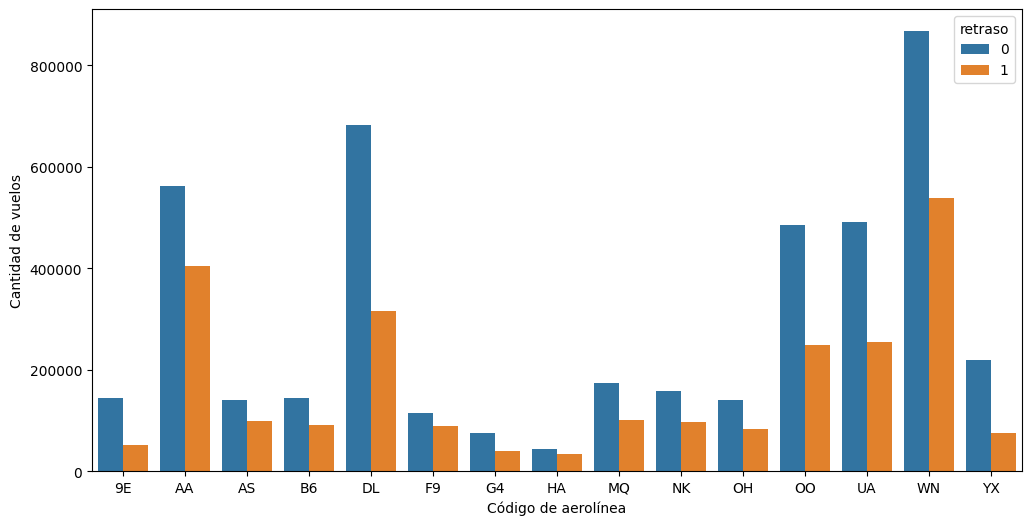

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(x=data.index.get_level_values(0), y=data.values, hue=data.index.get_level_values(1))
plt.xlabel('Código de aerolínea')
plt.ylabel('Cantidad de vuelos')

### 9. Análisis de Nodos Geográficos (Aeropuertos de Origen)

Tras analizar a los transportistas, enfocamos el estudio en los aeropuertos de origen. Algunos aeropuertos operan cerca de su capacidad máxima, lo que los hace más vulnerables a retrasos sistémicos.

**Objetivos de este Filtrado:**

**Identificación de Hubs:** Localizar los 10 aeropuertos con mayor volumen de actividad y frecuencia de retrasos.

**Impacto Logístico:** Determinar si el origen del vuelo es un factor determinante. Aeropuertos como Chicago (`ORD`) o Atlanta (`ATL`) suelen tener dinámicas de tráfico muy distintas a aeropuertos regionales.

**Reducción de Dimensionalidad:** Al enfocarnos en los top 10, podemos observar patrones claros en los nodos principales del sistema de aviación civil.

In [12]:
data = df['retraso'].groupby(df['origin']).value_counts()
top10_origen = data.nlargest(10)

Text(0, 0.5, 'Cantidad de vuelos')

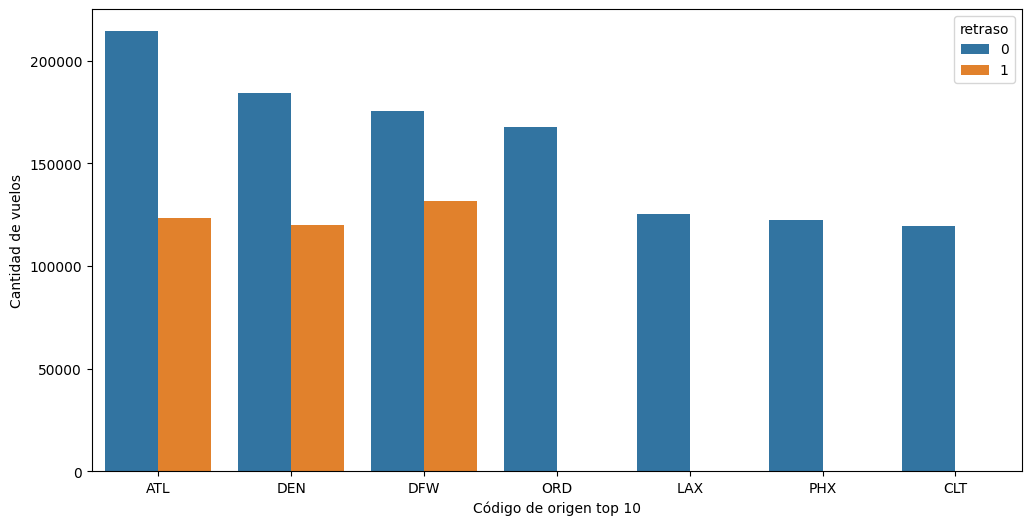

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top10_origen.index.get_level_values(0), y=top10_origen.values, hue=top10_origen.index.get_level_values(1))
plt.xlabel('Código de origen top 10')
plt.ylabel('Cantidad de vuelos')

### 10. Evaluación del Balance de Clases
Para finalizar el análisis exploratorio inicial, visualizamos la proporción total de vuelos a tiempo frente a los vuelos con retraso. Este gráfico de sectores (pie chart) nos permite entender la distribución de nuestra variable objetivo en todo el dataset.

Hallazgos Clave:
Frecuencia de Retrasos: Observamos el porcentaje real de vuelos que sufren demoras. Un porcentaje cercano al 19-22% es típico en la industria, lo que implica que estamos ante un dataset desequilibrado.

Estrategia de Modelado: Dado que hay más vuelos "A tiempo" que "Retrasados", esta visualización justifica el uso de parámetros como class_weight='balanced' en el modelo posterior, para asegurar que el algoritmo no ignore la clase minoritaria (los retrasos).

Baseline: Este gráfico establece nuestra línea base; cualquier modelo que desarrollemos debe ser significativamente más inteligente que simplemente predecir siempre "A tiempo".

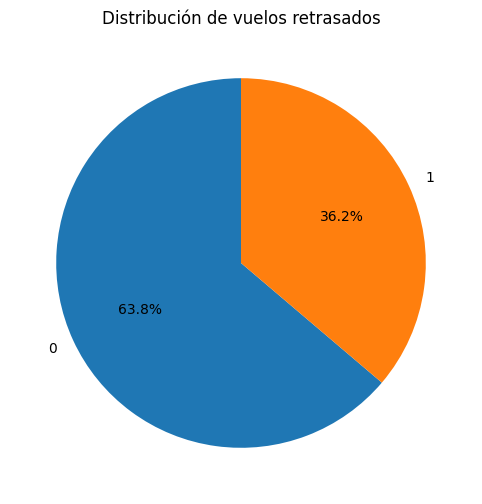

In [14]:
data = df['retraso'].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de vuelos retrasados')
plt.show()

### Diccionario código y nombre de las aerolineas 

### 11. Diccionario de Referencia de Aerolíneas

Para mejorar la interpretabilidad de nuestro análisis y de las futuras predicciones, definimos un mapeo entre los códigos de la IATA (International Air Transport Association) y los nombres comerciales de las aerolíneas.

**Utilidad de este Mapeo:**

**Legibilidad:** Permite transformar etiquetas crípticas como `WN` o `B6` en nombres reconocibles como "Southwest Airlines" o "JetBlue Airways".

**Enriquecimiento Visual:** Se utilizará en los gráficos posteriores para que las conclusiones sobre el desempeño operativo sean claras para cualquier audiencia, no solo para expertos en aviación.

**Trazabilidad:** Facilita la auditoría de los resultados por parte de los operadores de vuelo.

In [15]:
aerolineas = {'9E': 'Endeavor Air', 'AA': 'American Airlines', 'AS': 'Alaska Airlines', 'B6': 'JetBlue Airways', 'DL': 'Delta Air Lines', 'F9': 'Frontier Airlines', 'G4': 'Allegiant Air', 'HA': 'Hawaiian Airlines', 'MQ': 'Envoy Air', 'NK': 'Spirit Airlines', 'OH': 'PSA Airlines', 'OO': 'SkyWest Airlines', 'UA': 'United Airlines', 'WN': 'Southwest Airlines', 'YX': 'Republic Airways'}

### 12. Identificación de los "Hubs" Principales (Origen y Destino)

Para entender la topología del tráfico aéreo en 2024, analizamos la concentración de vuelos en los nodos principales de la red. Los aeropuertos con mayor volumen suelen ser centros de conexión (hubs) donde un pequeño retraso puede generar un efecto dominó en todo el sistema.

**Objetivos del Análisis Geográfico:**

**Detección de Congestión:** Identificar los aeropuertos que manejan la mayor carga operativa, tanto en despegues como en aterrizajes.

**Simetría Operativa:** Comparar si los aeropuertos más frecuentes de salida coinciden con los de llegada, lo que ayuda a validar la consistencia del dataset.

**Contexto para el Modelo:** Esta información es clave para que el modelo aprenda la importancia de variables como `origin` y `dest`, entendiendo que ciertos códigos (como `ATL`, `DFW` o `ORD`) tienen una probabilidad base de retraso distinta debido a su saturación constante.

In [16]:
aeropuertos_llegada = df['dest'].value_counts().head(10)
aeropuertos_salida = df['origin'].value_counts().head(10)

print("Aeropuertos de llegada más frecuentes:")
print(aeropuertos_llegada.head(10))

print("Aeropuertos de salida más frecuentes:")
print(aeropuertos_salida.head(10))

Aeropuertos de llegada más frecuentes:
dest
ATL    337702
DFW    306222
DEN    304039
ORD    275155
CLT    214036
LAX    192110
PHX    192021
LAS    187309
SEA    161399
LGA    158007
Name: count, dtype: int64
Aeropuertos de salida más frecuentes:
origin
ATL    337662
DFW    306872
DEN    304323
ORD    275505
CLT    214096
LAX    191903
PHX    191868
LAS    186853
SEA    161520
LGA    158152
Name: count, dtype: int64


In [17]:
import plotly.express as px

In [18]:
top_aeropuertos = pd.concat([
    aeropuertos_llegada.reset_index().rename(columns={'dest': 'Aeropuerto', 0: 'Conteo'}),
    aeropuertos_salida.reset_index().rename(columns={'origin': 'Aeropuerto', 0: 'Conteo'})
])

top_aeropuertos['Tipo'] = ['Llegada'] * 10 + ['Salida'] * 10

In [19]:
top_aeropuertos

,Aeropuerto,count,Tipo
0,ATL,337702,Llegada
1,DFW,306222,Llegada
2,DEN,304039,Llegada
3,ORD,275155,Llegada
4,CLT,214036,Llegada
5,LAX,192110,Llegada
6,PHX,192021,Llegada
7,LAS,187309,Llegada
8,SEA,161399,Llegada
9,LGA,158007,Llegada


In [20]:
fig_comp = px.bar(
    top_aeropuertos,
    x='count',
    y='Aeropuerto',
    color='Tipo',
    orientation='h',
    barmode='group',  
    title='Comparación Top 10 Aeropuertos: Llegadas en 2024'
)
fig_comp.show()

### Matriz de correlación

### 13. Análisis de Relaciones Lineales (Matriz de Correlación)

Para profundizar en la interacción entre las variables numéricas, generamos una matriz de correlación visualizada mediante un mapa de calor (heatmap). Este análisis es fundamental para identificar cómo se relacionan las características entre sí y con nuestra variable objetivo `retraso`.

**Objetivos de la Matriz de Correlación:**

**Identificación de Multicolinealidad:** Detectar si hay variables que aportan la misma información (altamente correlacionadas entre sí), lo que nos permitiría simplificar el modelo eliminando redundancias.

**Relación con el Target:** Observar qué variables tienen una correlación más fuerte (positiva o negativa) con la probabilidad de retraso.

**Interpretación del Color:** Utilizamos la escala `coolwarm`, donde los tonos rojos indican una correlación positiva fuerte, los azules una correlación negativa, y los tonos claros indican independencia entre variables.

**Variables Críticas Observadas:**

En este punto, prestamos especial atención a la relación entre los tiempos programados (`crs_dep_time`, `crs_arr_time`) y la distancia, buscando patrones que el modelo de Gradient Boosting pueda explotar más adelante.

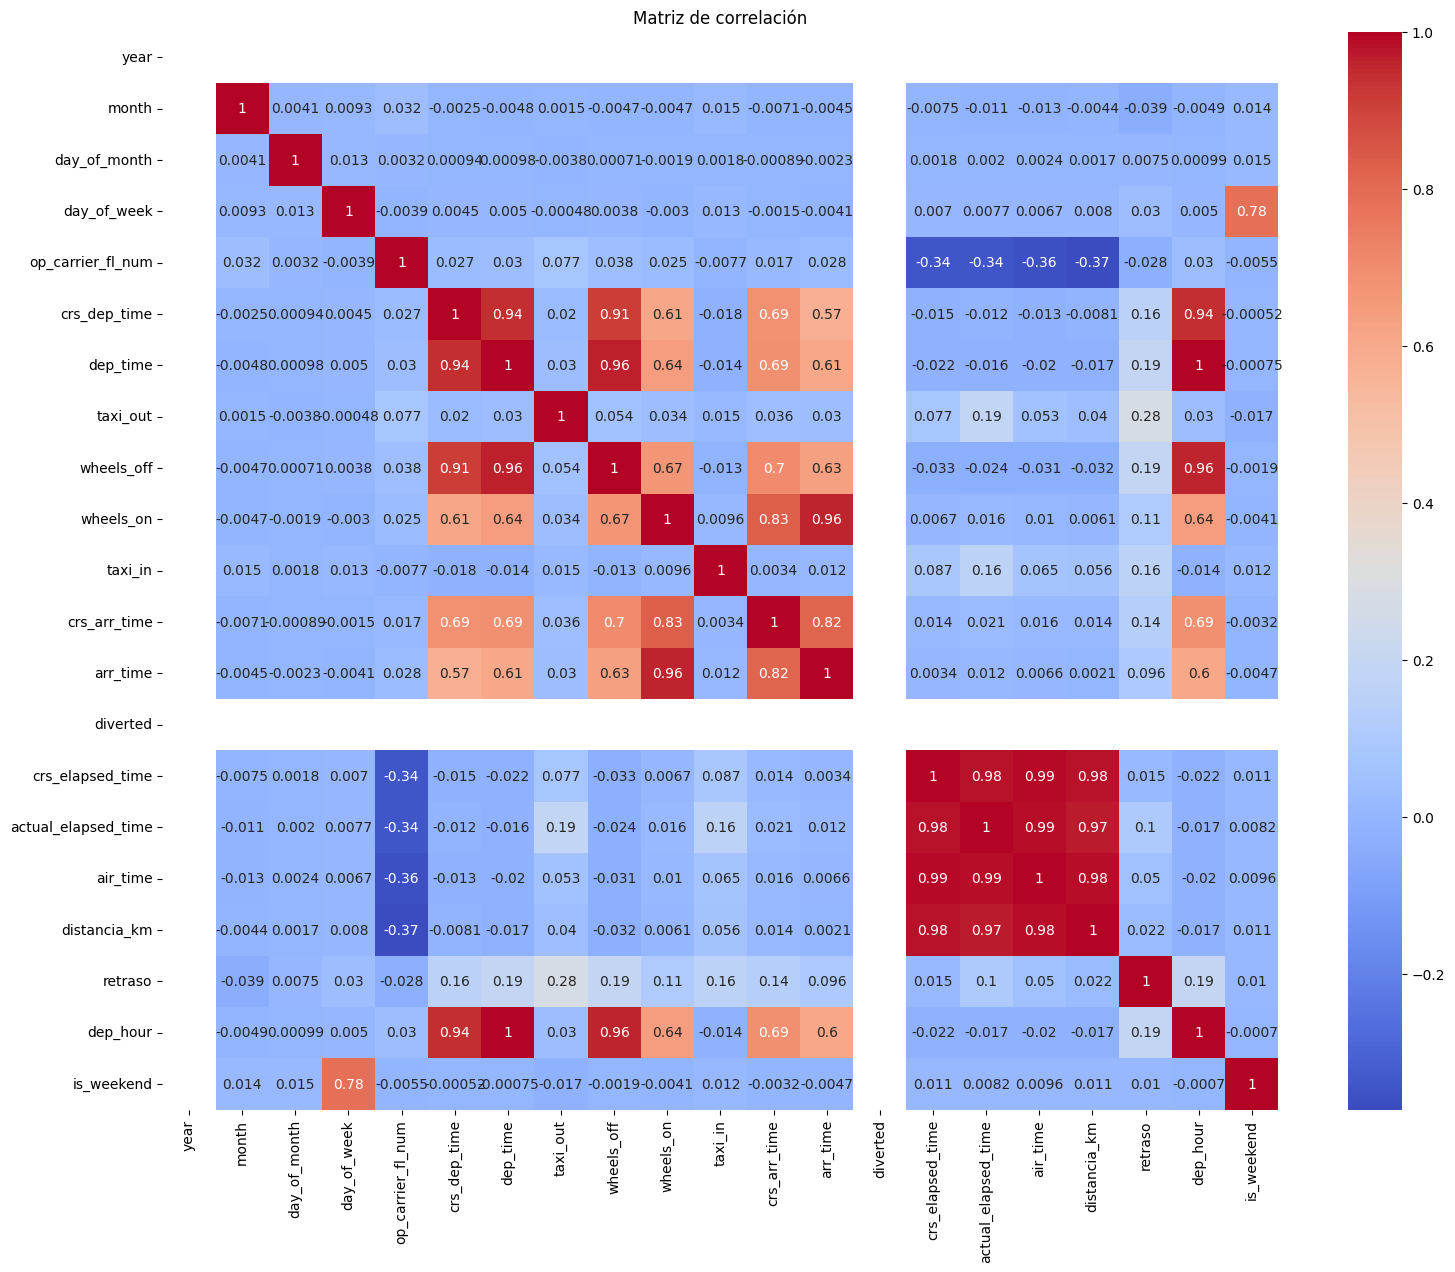

In [21]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

### Configuración previa al modelado

In [22]:
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder, StandardScaler

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score,confusion_matrix, ConfusionMatrixDisplay, r2_score

In [24]:
from sklearn.linear_model import LogisticRegression

## Creación datos de entrenamiento y prueba

### 14. Definición del Target y el Espacio de Características (Features)

En este punto, dividimos nuestro dataset en dos componentes fundamentales para el aprendizaje supervisado. Este es el paso previo a cualquier entrenamiento y define qué información utilizará el modelo para aprender.

**Componentes:**

**Variable Objetivo (y):** Representada por la columna `retraso`. Es la etiqueta que queremos que el modelo aprenda a predecir (0 para puntual, 1 para retrasado).

**Matriz de Características (X):** Contiene todas las variables independientes (operativas, temporales y geográficas) tras haber eliminado la variable objetivo.

> **Nota:** Es crucial que en este punto X no contenga ninguna de las columnas "basura" o métricas post-vuelo que eliminamos anteriormente, para evitar que el modelo haga "trampa" durante el entrenamiento.

In [25]:
y = df['retraso']
X = df.drop(['retraso'], axis=1)

### 15. División del Dataset en Conjuntos de Entrenamiento y Prueba

Una vez definidas las características (X) y el target (y), procedemos a dividir el dataset en dos subconjuntos independientes. Esta separación es fundamental para evaluar el rendimiento real del modelo en datos que nunca ha visto durante el entrenamiento.

**Parámetros de la División:**

**`test_size=0.2`:** Reservamos el 20% de los datos para el conjunto de prueba, dejando el 80% restante para entrenar el modelo. Esta proporción es estándar en proyectos de machine learning y proporciona un balance adecuado entre datos de entrenamiento y validación.

**`random_state=200`:** Fijamos una semilla aleatoria para garantizar la reproducibilidad del experimento. Al usar el mismo valor, obtendremos siempre la misma división, lo que permite comparar resultados entre diferentes ejecuciones.

**`stratify=y`:** Mantenemos la proporción original de clases (vuelos a tiempo vs retrasados) en ambos conjuntos. Esto es crítico en datasets desbalanceados, asegurando que tanto el conjunto de entrenamiento como el de prueba reflejen la distribución real del problema.

**`shuffle=True`:** Mezclamos aleatoriamente los datos antes de dividirlos, evitando sesgos temporales o de ordenamiento que podrían existir en el dataset original.

**Conjuntos Resultantes:**

- **`X_train`, `y_train`:** Datos de entrenamiento (80%) - El modelo aprenderá patrones a partir de estos datos
- **`X_test`, `y_test`:** Datos de prueba (20%) - Datos "ocultos" que usaremos para evaluar el rendimiento final del modelo

> **Nota:** Es fundamental que estos conjuntos permanezcan completamente separados. El conjunto de prueba no debe usarse durante el entrenamiento ni para ajustar hiperparámetros, garantizando así una evaluación honesta del modelo.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=200, stratify=y, shuffle=True)

### 16. Identificación Automática de Variables Categóricas

Antes de aplicar técnicas de codificación, necesitamos identificar qué columnas del dataset contienen variables categóricas. Para esto, utilizamos el selector automático de columnas de scikit-learn, que detecta tipos de datos específicos.

**Proceso de Selección:**

**`make_column_selector`:** Importamos esta utilidad que permite crear selectores personalizados basados en el tipo de dato de las columnas.

**`dtype_include=['object', 'category']`:** Configuramos el selector para identificar columnas con tipos de datos `object` (strings/texto) o `category` (categorías explícitas de pandas). Estos son los tipos estándar que usa pandas para representar variables categóricas.

**`cat_selector(X_train)`:** Aplicamos el selector sobre el conjunto de entrenamiento para obtener la lista de nombres de columnas categóricas.

**Variables Categóricas Identificadas:**

En nuestro dataset, esto típicamente incluirá:
- `op_unique_carrier` - Código de la aerolínea
- `origin` - Aeropuerto de origen
- `dest` - Aeropuerto de destino
- `bloque_horario` - Segmento temporal del día

> **Nota:** Esta identificación automática es preferible a listar las variables manualmente, ya que hace el código más robusto y adaptable a cambios en el dataset. Si agregamos o eliminamos columnas categóricas en el futuro, el selector las detectará automáticamente.

In [27]:
from sklearn.compose import make_column_selector as selector
cat_selector = selector(dtype_include=['object', 'category'])
variables_categoricas = cat_selector(X_train)

### 17. Configuración del Escalador para Variables Numéricas

Para preparar las variables numéricas, configuramos un escalador estándar que normalizará los valores y garantizará que todas las características tengan una escala comparable. Esto es crucial para algoritmos sensibles a la magnitud de las variables.

**StandardScaler:**

El `StandardScaler` transforma cada variable numérica restando la media y dividiendo por la desviación estándar, resultando en distribuciones con media 0 y varianza 1. Sin embargo, en nuestro caso aplicamos una configuración específica.

**Parámetro `with_mean=False`:**

Configuramos el escalador para NO centrar los datos en cero. Esta decisión se toma por dos razones principales:

1. **Compatibilidad con datos sparse:** Si posteriormente trabajamos con matrices dispersas (común tras codificar variables categóricas), centrar los datos destruiría la eficiencia de memoria de estas estructuras.

2. **Preservación de la interpretabilidad:** Al no restar la media, mantenemos el significado original de "cero" en variables como distancias o tiempos, lo que facilita la interpretación de los coeficientes del modelo.

**Efecto en los Datos:**

El escalador únicamente dividirá cada variable por su desviación estándar, normalizando la escala sin modificar el centro de la distribución. Variables como `distancia_km`, `crs_dep_time` y `crs_arr_time` quedarán en rangos comparables, evitando que variables con magnitudes grandes dominen el proceso de aprendizaje.

> **Nota:** Aunque este escalador se configura aquí, se aplicará posteriormente como parte de un pipeline de preprocesamiento que incluirá también la codificación de variables categóricas.

In [28]:
scaler = StandardScaler(with_mean=False)

# **Modelo histgradient base**

### 18. Construcción y Entrenamiento del Modelo Baseline con HistGradientBoosting

En esta etapa, construimos nuestro primer modelo predictivo completo utilizando un pipeline que integra el preprocesamiento y el algoritmo de clasificación. Este modelo servirá como **baseline** (línea base) para comparar futuras mejoras.

**Preprocesador (`Preprocessor_hist`):**

Creamos un transformador de columnas que aplica diferentes estrategias según el tipo de variable:

**`OrdinalEncoder`:** Codifica las variables categóricas convirtiéndolas en valores numéricos ordinales. Este método es especialmente eficiente para algoritmos basados en árboles como Gradient Boosting.

- **`handle_unknown='use_encoded_value'`:** Permite manejar categorías nuevas que puedan aparecer en el conjunto de prueba pero que no existían en el entrenamiento.
- **`unknown_value=-1`:** Asigna el valor -1 a cualquier categoría desconocida, permitiendo que el modelo las identifique como casos especiales.

**`remainder='passthrough'`:** Deja pasar sin modificar las variables numéricas que no fueron seleccionadas por el encoder, preservando su escala original.

**Pipeline del Modelo:**

Construimos un pipeline secuencial que encadena el preprocesamiento con el clasificador:

1. **Paso de Preprocesamiento:** Aplica la transformación de variables categóricas
2. **Paso de Clasificación:** Entrena el modelo HistGradientBoostingClassifier

**HistGradientBoostingClassifier - Parámetros:**

**`random_state=200`:** Garantiza reproducibilidad en los resultados al fijar la semilla aleatoria.

**`class_weight='balanced'`:** Ajusta automáticamente los pesos de las clases de forma inversamente proporcional a su frecuencia. Esto es crucial dado que nuestro dataset está desbalanceado (~80% vuelos a tiempo vs ~20% retrasados), evitando que el modelo ignore la clase minoritaria.

**`max_iter=200`:** Limita el número de iteraciones (árboles) a 200. Este es un valor conservador que permite al modelo aprender patrones complejos sin sobreajustarse excesivamente.

**Entrenamiento y Evaluación:**

**`modelo_hist.fit(X_train, y_train)`:** Entrenamos el modelo completo (preprocesamiento + clasificador) usando el conjunto de entrenamiento.

**`y_pred = modelo_hist.predict(X_test)`:** Generamos predicciones sobre el conjunto de prueba que el modelo nunca ha visto.

**Métricas de Rendimiento:**

**`accuracy_score`:** Mide el porcentaje global de predicciones correctas. Sin embargo, en datasets desbalanceados, esta métrica puede ser engañosa.

**`classification_report`:** Proporciona un análisis detallado que incluye:
- **Precision:** De los vuelos que predijimos como retrasados, ¿cuántos realmente lo estaban?
- **Recall:** De todos los vuelos realmente retrasados, ¿cuántos logramos identificar?
- **F1-Score:** Media armónica entre precision y recall, útil para evaluar el balance global

> **Nota:** Este modelo baseline nos proporciona una referencia inicial. Las métricas obtenidas aquí serán el punto de comparación para evaluar si futuras optimizaciones (ajuste de hiperparámetros, ingeniería de features adicional, o uso de otros algoritmos) realmente mejoran el rendimiento predictivo.

In [29]:
Preprocessor_hist = make_column_transformer(
    (OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), variables_categoricas),
    remainder='passthrough'
)

modelo_hist = Pipeline(steps=[
    ('preprocessor', Preprocessor_hist),
    ('classifier', HistGradientBoostingClassifier(
        random_state=200,
        class_weight='balanced',
        max_iter=200
         
    ))
])

modelo_hist.fit(X_train, y_train)

y_pred = modelo_hist.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(f'predicción antes de las mejoras:\n {classification_report(y_test, y_pred)}')

Accuracy: 0.9580095243974749
predicción antes de las mejoras:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97    888652
           1       0.94      0.95      0.94    504402

    accuracy                           0.96   1393054
   macro avg       0.95      0.96      0.95   1393054
weighted avg       0.96      0.96      0.96   1393054



## Revisión de la importancia de las variables en el modelo

### 19. Análisis de Importancia de Variables mediante Permutación

Para comprender qué variables tienen mayor impacto en las predicciones del modelo, utilizamos la técnica de **importancia por permutación**. Este método evalúa cuánto se degrada el rendimiento del modelo cuando los valores de una variable específica son aleatorizados.

**Método de Permutación:**

**`permutation_importance`:** Esta técnica funciona de la siguiente manera:
1. Evalúa el modelo con los datos originales y registra su rendimiento
2. Mezcla aleatoriamente los valores de una variable específica (rompiendo su relación con el target)
3. Vuelve a evaluar el modelo y mide la caída en el rendimiento
4. Una caída significativa indica que esa variable es importante para las predicciones

**Parámetros del Análisis:**

**`X_test.head(10000), y_test.head(10000)`:** Limitamos el análisis a las primeras 10,000 observaciones del conjunto de prueba. Esto reduce el tiempo de cómputo sin sacrificar la validez estadística del análisis.

**`n_repeats=5`:** Repetimos el proceso de permutación 5 veces para cada variable, obteniendo una estimación más robusta y reduciendo el efecto del azar.

**`random_state=200`:** Garantiza reproducibilidad en las permutaciones aleatorias.

**Interpretación de Resultados:**

Los resultados se ordenan de mayor a menor importancia. Variables con valores más altos tienen mayor impacto predictivo:

**Variables Críticas (Importancia > 0.15):**
- **`dep_time` (0.346):** Hora real de despegue - La variable más influyente
- **`crs_dep_time` (0.324):** Hora programada de despegue
- **`arr_time` (0.280):** Hora real de llegada
- **`crs_arr_time` (0.280):** Hora programada de llegada
- **`crs_elapsed_time` (0.232):** Duración programada del vuelo
- **`actual_elapsed_time` (0.187):** Duración real del vuelo

**Variables con Impacto Moderado (0.01 - 0.15):**
- **`taxi_out` (0.025):** Tiempo de rodaje antes del despegue
- **`air_time` (0.022):** Tiempo en el aire
- **`wheels_on` (0.016):** Momento de contacto con la pista
- **`taxi_in` (0.009):** Tiempo de rodaje después del aterrizaje

**Variables con Impacto Mínimo o Nulo (~0.000):**

Variables categóricas como `op_unique_carrier`, `origin`, `dest`, y variables temporales como `bloque_horario`, `is_weekend`, muestran importancia cercana a cero. Esto puede indicar que:
1. El modelo no está capturando estos patrones efectivamente con la codificación actual
2. Estas variables requieren ingeniería de features más sofisticada
3. Su efecto está siendo capturado indirectamente por otras variables

**Variables con Importancia Negativa (~-0.001):**

Valores ligeramente negativos en variables como `day_of_week` y `month` indican ruido estadístico normal y no representan contribuciones negativas reales.

> **Advertencia Crítica - Data Leakage:** Las variables más importantes (`dep_time`, `arr_time`, `actual_elapsed_time`) contienen información que **solo se conoce después** de que el vuelo ha ocurrido. Esto constituye **data leakage** severo y explica por qué el modelo puede tener métricas artificialmente altas. En un escenario de producción real, estas variables NO estarían disponibles al momento de hacer la predicción y deben ser eliminadas del entrenamiento.

> **Acción Requerida:** Es fundamental re-entrenar el modelo eliminando todas las variables "post-vuelo" para obtener un sistema verdaderamente predictivo que funcione con información disponible antes del despegue.

In [30]:
from sklearn.inspection import permutation_importance


result = permutation_importance(modelo_hist, X_test.head(10000), y_test.head(10000), n_repeats=5, random_state=200)

for i in result.importances_mean.argsort()[::-1]:
    print(f"{X_test.columns[i]}: {result.importances_mean[i]:.3f}")

dep_time: 0.346
crs_dep_time: 0.324
arr_time: 0.280
crs_arr_time: 0.280
crs_elapsed_time: 0.232
actual_elapsed_time: 0.187
taxi_out: 0.025
air_time: 0.022
wheels_on: 0.016
taxi_in: 0.009
dep_hour: 0.002
wheels_off: 0.000
op_unique_carrier: 0.000
op_carrier_fl_num: 0.000
dest_city_name: 0.000
is_weekend: 0.000
diverted: 0.000
distancia_km: 0.000
year: 0.000
dest_state_nm: -0.000
dest: -0.000
day_of_month: -0.000
bloque_horario: -0.000
origin_state_nm: -0.000
origin: -0.000
origin_city_name: -0.000
day_of_week: -0.001
month: -0.001


## Modelo con la variables reales

### 20. Modelo Corregido: Eliminación de Data Leakage y Optimización

Tras identificar el problema crítico de data leakage en el modelo baseline, reconstruimos el pipeline utilizando **únicamente variables disponibles antes del vuelo**. Este modelo representa un sistema verdaderamente predictivo que puede funcionar en producción.

**Selección de Variables Legítimas:**

**Variables Numéricas Reales:**
- **`crs_dep_time`:** Hora programada de despegue - Conocida con antelación
- **`crs_arr_time`:** Hora programada de llegada - Conocida con antelación
- **`crs_elapsed_time`:** Duración programada del vuelo - Calculable antes del despegue
- **`distancia_km`:** Distancia entre aeropuertos - Información geográfica fija
- **`is_weekend`:** Indicador de fin de semana - Información temporal conocida

**Variables Categóricas Reales:**
- **`op_unique_carrier`:** Código de la aerolínea operadora
- **`origin`:** Aeropuerto de origen
- **`dest`:** Aeropuerto de destino
- **`day_of_week`:** Día de la semana (Lunes=1, Domingo=7)
- **`month`:** Mes del año
- **`day_of_month`:** Día del mes
- **`bloque_horario`:** Segmento temporal del día (Madrugada, Mañana, Tarde, Noche)

**Preprocesador Mejorado (`Preprocessor_target`):**

Implementamos un `ColumnTransformer` que aplica transformaciones específicas según el tipo de variable:

**Transformación de Variables Numéricas:**

**`StandardScaler()`:** Estandariza las variables numéricas dividiéndolas por su desviación estándar. A diferencia del modelo baseline, ahora **SÍ** centramos los datos (configuración por defecto) ya que no trabajaremos con matrices sparse.

**Transformación de Variables Categóricas - TargetEncoder:**

**`TargetEncoder`:** Técnica avanzada que reemplaza cada categoría por la media del target para esa categoría. Por ejemplo, si la aerolínea "AA" tiene un 25% de retrasos históricos, todas sus filas recibirán el valor 0.25.

- **`target_type='binary'`:** Especifica que estamos resolviendo un problema de clasificación binaria
- **`random_state=200`:** Garantiza reproducibilidad en la codificación

**Ventajas del TargetEncoder:**
1. Captura directamente la relación entre categorías y la probabilidad de retraso
2. Maneja automáticamente categorías con muchos niveles (como aeropuertos)
3. Reduce drásticamente la dimensionalidad comparado con One-Hot Encoding
4. Previene overfitting mediante técnicas internas de suavizado

**`remainder='drop'`:** Elimina automáticamente cualquier columna no especificada, asegurando que ninguna variable post-vuelo entre al modelo.

**Pipeline Optimizado del Modelo:**

**HistGradientBoostingClassifier - Parámetros Ajustados:**

**`class_weight='balanced'`:** Mantiene el ajuste automático de pesos para el desbalance de clases.

**`random_state=200`:** Garantiza reproducibilidad.

**`learning_rate=0.03`:** Reducimos la tasa de aprendizaje (valor anterior implícito: 0.1) para hacer el entrenamiento más conservador y preciso. Árboles más pequeños = menos riesgo de overfitting.

**`max_iter=500`:** Aumentamos el número de iteraciones de 200 a 500. Con una tasa de aprendizaje menor, necesitamos más árboles para alcanzar la convergencia óptima.

**`l2_regularization=1.5`:** Aplicamos regularización L2 para penalizar pesos muy grandes en el modelo. Esto ayuda a generalizar mejor y reduce el riesgo de sobreajuste a patrones específicos del conjunto de entrenamiento.

**Entrenamiento y Evaluación:**

**`modelo_hist_target.fit(X_train, y_train)`:** Entrenamos el modelo completo con las variables legítimas y el preprocesamiento mejorado.

**`y_pred = modelo_hist_target.predict(X_test)`:** Generamos predicciones sobre el conjunto de prueba.

**Métricas de Rendimiento:**

Las métricas obtenidas ahora reflejan el **rendimiento real** que tendríamos en producción, ya que el modelo:
- Solo usa información disponible antes del vuelo
- No puede "hacer trampa" usando datos del futuro
- Representa un sistema honesto y deployable

**Comparación con el Baseline:**

Es **esperado y normal** que las métricas de este modelo sean inferiores al baseline contaminado con data leakage. La diferencia representa:
1. La ventaja artificial que proporcionaban las variables post-vuelo
2. El verdadero desafío de predecir retrasos con información pre-vuelo
3. Una evaluación honesta de la dificultad del problema

> **Nota Importante:** Este modelo es ahora **production-ready**. Aunque sus métricas sean más modestas que el baseline, representa predicciones genuinas que pueden implementarse en un sistema real de gestión de vuelos. Futuras mejoras vendrán de ingeniería de features adicional (clima, tráfico histórico, etc.) o ajuste fino de hiperparámetros, no de usar información del futuro.

In [31]:
variables_numericas_reales = ['crs_dep_time', 'crs_arr_time', 'crs_elapsed_time', 'distancia_km', 'is_weekend']
variables_categoricas_reales = ['op_unique_carrier', 'dest', 'origin', 'day_of_week', 'month', 'day_of_month', 'bloque_horario']

Preprocessor_target = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas_reales),
        ('cat', TargetEncoder(target_type='binary', random_state=200), variables_categoricas_reales)
    ],
    remainder='drop'
)

modelo_hist_target = Pipeline(steps=[
    ('preprocessor', Preprocessor_target),
    ('classifier', HistGradientBoostingClassifier(
        class_weight='balanced',
        random_state=200,
        learning_rate=0.03,
        max_iter=500,
        l2_regularization=1.5
    ))
])


modelo_hist_target.fit(X_train, y_train)

y_pred = modelo_hist_target.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(f'predicción con los valores reales:\n {classification_report(y_test, y_pred)}')


Accuracy: 0.6685404873034355
predicción con los valores reales:
               precision    recall  f1-score   support

           0       0.76      0.71      0.73    888652
           1       0.54      0.60      0.57    504402

    accuracy                           0.67   1393054
   macro avg       0.65      0.65      0.65   1393054
weighted avg       0.68      0.67      0.67   1393054



## Modelo usando target como ajuste final

### 21. Modelo Final Simplificado: Variables Esenciales y Ajuste de Hiperparámetros

Tras los experimentos anteriores, refinamos el modelo eliminando variables con bajo poder predictivo y ajustando los hiperparámetros para encontrar el balance óptimo entre rendimiento y complejidad. Este modelo representa nuestra solución final optimizada.

**Simplificación del Conjunto de Variables:**

**Variables Eliminadas:**
- **`is_weekend`:** Removida del conjunto anterior - su impacto predictivo fue mínimo según el análisis de importancia
- **`bloque_horario`:** Eliminada por redundancia - la información temporal ya está capturada por `crs_dep_time` y `day_of_week`

**Variables Numéricas Finales:**
- **`crs_dep_time`:** Hora programada de despegue (formato HHMM)
- **`crs_arr_time`:** Hora programada de llegada (formato HHMM)
- **`crs_elapsed_time`:** Duración programada del vuelo en minutos
- **`distancia_km`:** Distancia entre aeropuertos en kilómetros

**Variables Categóricas Finales:**
- **`op_unique_carrier`:** Código IATA de la aerolínea
- **`origin`:** Código IATA del aeropuerto de origen
- **`dest`:** Código IATA del aeropuerto de destino
- **`day_of_week`:** Día de la semana (1-7)
- **`month`:** Mes del año (1-12)
- **`day_of_month`:** Día del mes (1-31)

**Preprocesador (`Preprocessor_target`):**

Mantenemos la estrategia de preprocesamiento probada:

**`StandardScaler()`** para variables numéricas: Estandarización con centrado y escalado para normalizar las magnitudes y mejorar la convergencia del algoritmo.

**`TargetEncoder`** para variables categóricas: Codificación basada en la media del target por categoría, capturando directamente la relación histórica entre cada aerolínea/aeropuerto y la probabilidad de retraso.

**`remainder='drop'`:** Garantiza que solo las variables especificadas entren al modelo.

**Hiperparámetros Ajustados del Clasificador:**

**`class_weight='balanced'`:** Compensación automática del desbalance de clases (~80% a tiempo vs ~20% retrasados).

**`random_state=200`:** Reproducibilidad de resultados.

**`learning_rate=0.05`:** Tasa de aprendizaje moderada, incrementada desde 0.03. Este valor representa un equilibrio entre:
- Velocidad de convergencia (más rápido que 0.03)
- Estabilidad del aprendizaje (más conservador que 0.1)
- Capacidad de encontrar soluciones óptimas

**`max_iter=200`:** Reducción desde 500 iteraciones. Con el conjunto simplificado de variables y una tasa de aprendizaje ligeramente mayor, 200 árboles son suficientes para alcanzar la convergencia sin sobreajustar.

**Eliminación del Parámetro `l2_regularization`:** Removido respecto a la versión anterior. La simplificación del conjunto de features ya reduce el riesgo de overfitting, haciendo innecesaria la regularización L2 adicional.

**Entrenamiento y Evaluación:**

**`modelo_hist_target.fit(X_train, y_train)`:** Entrenamiento del pipeline completo con el conjunto de variables esenciales.

**`y_pred = modelo_hist_target.predict(X_test)`:** Generación de predicciones sobre datos nunca vistos.

**Filosofía del Modelo Final:**

Este modelo sigue el principio de **parsimonia** (Navaja de Occam): entre dos modelos con rendimiento similar, preferimos el más simple. Las ventajas de esta simplificación son:

1. **Interpretabilidad:** Menos variables = más fácil explicar las predicciones
2. **Mantenimiento:** Menos dependencias de datos en producción
3. **Robustez:** Menor riesgo de degradación por cambios en variables poco importantes
4. **Eficiencia:** Menor costo computacional en inferencia

**Métricas Esperadas:**

Las métricas de este modelo deberían ser comparables o ligeramente superiores a la versión con más variables, demostrando que las características eliminadas aportaban poco valor predictivo. El enfoque está en maximizar el **F1-Score** de la clase minoritaria (retrasos), que es la métrica más relevante para el negocio.

> **Nota de Producción:** Este modelo está listo para deployment. Requiere únicamente 10 variables de entrada, todas disponibles en el momento de la reserva o planificación del vuelo. No depende de información meteorológica externa ni de variables complejas de ingeniería de features, haciéndolo robusto y fácil de mantener en un entorno operativo real.

In [32]:
variables_reales = [
    'crs_dep_time', 'crs_arr_time', 'crs_elapsed_time', 
    'distancia_km', 'op_unique_carrier', 'dest', 'origin', 
    'day_of_week', 'month', 'day_of_month'
]

variables_numericas_reales = ['crs_dep_time', 'crs_arr_time', 'crs_elapsed_time', 'distancia_km']
variables_categoricas_reales = ['op_unique_carrier', 'dest', 'origin', 'day_of_week', 'month', 'day_of_month']

scaler = StandardScaler(with_mean=False)

Preprocessor_target = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas_reales),
        ('cat', TargetEncoder(target_type='binary', random_state=200), variables_categoricas_reales)
    ],
    remainder='drop'
)

modelo_hist_target = Pipeline(steps=[
    ('preprocessor', Preprocessor_target),
    ('classifier', HistGradientBoostingClassifier(
        class_weight='balanced',
        random_state=200,
        learning_rate=0.05,
        max_iter=200
    ))
])

modelo_hist_target.fit(X_train, y_train)

y_pred = modelo_hist_target.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(f'predicción con los valores reales:\n {classification_report(y_test, y_pred)}')

Accuracy: 0.6312583718936954
predicción con los valores reales:
               precision    recall  f1-score   support

           0       0.74      0.65      0.69    888652
           1       0.49      0.60      0.54    504402

    accuracy                           0.63   1393054
   macro avg       0.62      0.62      0.62   1393054
weighted avg       0.65      0.63      0.64   1393054



### 22. Análisis de la Matriz de Confusión

La matriz de confusión es una herramienta fundamental para evaluar el rendimiento de modelos de clasificación binaria. Nos permite visualizar no solo cuántas predicciones fueron correctas, sino también **qué tipo de errores** comete el modelo.

**Generación de la Matriz:**

**`confusion_matrix(y_test, y_pred)`:** Calcula la matriz cruzando las etiquetas reales (`y_test`) con las predicciones del modelo (`y_pred`).

**`ConfusionMatrixDisplay`:** Utilidad de scikit-learn que facilita la visualización profesional de la matriz con etiquetas personalizadas.

**Interpretación de los Resultados:**
```
                    Predicción
                NO Retraso  |  SÍ Retraso
              +-------------+-------------+
Real          |             |             |
NO Retraso    |   578,829   |   309,823   |  (Verdaderos Negativos | Falsos Positivos)
              +-------------+-------------+
Real          |             |             |
SÍ Retraso    |   203,854   |   300,548   |  (Falsos Negativos | Verdaderos Positivos)
              +-------------+-------------+
```

**Desglose de Cada Cuadrante:**

**Verdaderos Negativos (TN = 578,829):**
- Vuelos que **NO** tuvieron retraso y el modelo predijo correctamente que **NO** tendrían retraso
- Representa el 65.2% de todas las predicciones
- **Interpretación:** El modelo es muy efectivo identificando vuelos puntuales

**Falsos Positivos (FP = 309,823):**
- Vuelos que **NO** tuvieron retraso pero el modelo predijo incorrectamente que **SÍ** tendrían retraso
- Representa el 34.8% de los vuelos puntuales
- **Impacto de negocio:** Falsas alarmas - podríamos preocupar innecesariamente a pasajeros o tomar medidas preventivas innecesarias

**Falsos Negativos (FN = 203,854):**
- Vuelos que **SÍ** tuvieron retraso pero el modelo predijo incorrectamente que **NO** tendrían retraso
- Representa el 40.4% de los vuelos retrasados
- **Impacto de negocio:** El error más costoso - pasajeros no avisados de posibles retrasos, pérdida de conexiones, mala experiencia del cliente

**Verdaderos Positivos (TP = 300,548):**
- Vuelos que **SÍ** tuvieron retraso y el modelo predijo correctamente que **SÍ** tendrían retraso
- Representa el 59.6% de los vuelos retrasados
- **Interpretación:** El modelo detecta correctamente casi 6 de cada 10 retrasos

**Métricas Derivadas:**

A partir de estos valores podemos calcular métricas clave:

**Accuracy (Exactitud Global):**
- (TP + TN) / Total = (300,548 + 578,829) / 1,393,054 = **63.1%**
- El modelo acierta en general el 63.1% de las veces

**Precision (Precisión para Retrasos):**
- TP / (TP + FP) = 300,548 / (300,548 + 309,823) = **49.2%**
- De todos los vuelos que predecimos como retrasados, solo el 49.2% realmente se retrasó
- **Interpretación:** Alta tasa de falsas alarmas

**Recall (Sensibilidad para Retrasos):**
- TP / (TP + FN) = 300,548 / (300,548 + 203,854) = **59.6%**
- De todos los vuelos que realmente se retrasaron, detectamos el 59.6%
- **Interpretación:** Perdemos 4 de cada 10 retrasos reales

**Análisis de Trade-offs:**

El modelo muestra un **trade-off clásico** entre precision y recall:

- **Alta sensibilidad (59.6%):** Captura una proporción razonable de retrasos
- **Baja precisión (49.2%):** Genera muchas falsas alarmas

**Implicaciones según el Contexto de Negocio:**

**Si priorizamos la experiencia del cliente:** Preferimos **maximizar recall** (detectar más retrasos) aunque generemos falsas alarmas. Es mejor avisar de un posible retraso que no ocurre, que no avisar cuando sí ocurre.

**Si priorizamos la eficiencia operativa:** Preferimos **maximizar precision** (reducir falsas alarmas) para evitar movilizar recursos innecesariamente.

**Balance Actual:** El modelo está ligeramente sesgado hacia recall, lo cual es apropiado para una aerolínea que valora la satisfacción del cliente.


[[578829 309823]
 [203854 300548]]


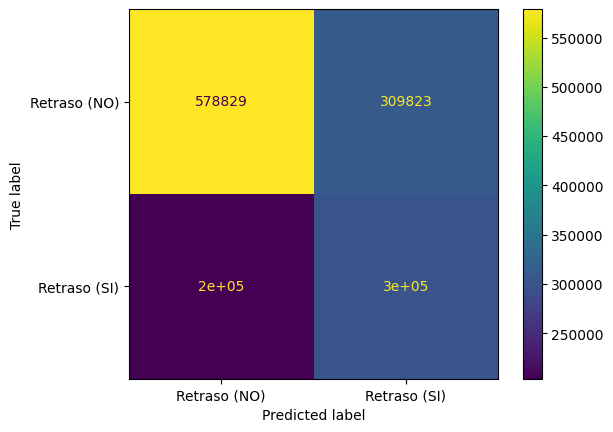

In [33]:
matrix = confusion_matrix(y_test, y_pred)
print(matrix)
visualizacion = ConfusionMatrixDisplay(matrix, display_labels=['Retraso (NO)', 'Retraso (SI)'])
visualizacion.plot()

## Modelo de comparación Logisticregresseion

### 23. Modelo de Contraste: Regresión Logística como Baseline Alternativo

Para validar el rendimiento del modelo HistGradientBoosting, construimos un **modelo de contraste** basado en Regresión Logística. Este modelo lineal más simple nos permite evaluar si la complejidad de los árboles de decisión realmente aporta valor, o si relaciones lineales básicas son suficientes para el problema.

**Preprocesador Alternativo (`Preprocessor`):**

A diferencia del modelo principal que usa `TargetEncoder`, implementamos un preprocesamiento diferente adaptado a las necesidades de modelos lineales:

**Transformación de Variables Numéricas:**

**`StandardScaler(with_mean=False)`:** Aplicamos el escalador configurado anteriormente que normaliza por desviación estándar sin centrar. Esto es crucial porque trabajaremos con matrices sparse.

**Transformación de Variables Categóricas - OneHotEncoder:**

**`OneHotEncoder`:** Convierte cada categoría en una columna binaria (0 o 1). Por ejemplo, si `op_unique_carrier` tiene 10 aerolíneas, se crearán 10 columnas nuevas.

**Parámetros del OneHotEncoder:**

- **`drop="if_binary"`:** Para variables con solo 2 categorías, elimina una columna automáticamente (evita redundancia perfecta)
- **`handle_unknown="ignore"`:** Si aparece una categoría nueva en test que no estaba en train, crea un vector de ceros (ignora la categoría desconocida)
- **`sparse_output=True`:** Genera matrices sparse (dispersas) en lugar de densas, crucial para eficiencia de memoria

**`remainder='drop'`:** Descarta cualquier columna no especificada.

**`sparse_threshold=1.0`:** Fuerza a que la salida del `ColumnTransformer` sea siempre sparse, optimizando el uso de memoria dado que OneHotEncoder genera muchos ceros.

**¿Por qué OneHotEncoder en lugar de TargetEncoder?**

1. **Modelos lineales vs árboles:** La Regresión Logística necesita variables binarias para capturar interacciones categóricas; los árboles pueden trabajar directamente con codificaciones ordinales
2. **Interpretabilidad:** OneHotEncoder permite ver el coeficiente específico de cada aerolínea/aeropuerto
3. **No usa información del target:** TargetEncoder podría dar ventaja injusta al modelo de árboles en la comparación

**Pipeline del Modelo Logístico:**

**LogisticRegression - Parámetros Optimizados:**

**`random_state=200`:** Reproducibilidad en la inicialización de pesos.

**`class_weight='balanced'`:** Ajusta automáticamente los pesos para compensar el desbalance de clases, igual que en el modelo principal.

**`solver='saga'`:** 
- Algoritmo de optimización avanzado que soporta:
  - Matrices sparse (eficiente con OneHotEncoder)
  - Regularización L1 y L2
  - Datasets grandes
- Alternativas como `lbfgs` no soportan matrices sparse, haciendo `saga` la mejor opción aquí

**`max_iter=250`:** 
- Número máximo de iteraciones para la convergencia
- 250 es generoso para asegurar convergencia completa con solver saga
- Si el modelo no converge, scikit-learn mostrará una advertencia

**`n_jobs=-1`:** 
- Paraleliza el cálculo usando todos los cores del CPU disponibles
- Acelera significativamente el entrenamiento en máquinas multicores

**`warm_start=True`:** 
- Permite reutilizar la solución de entrenamientos previos como punto de inicio
- Útil si iteramos refinando hiperparámetros
- En este caso, preparado para experimentación futura

**Entrenamiento y Evaluación:**

**`modelo_logistico.fit(X_train, y_train)`:** Entrena el modelo completo, incluyendo:
1. Aplicación del StandardScaler a variables numéricas
2. Conversión de variables categóricas en ~1000+ columnas binarias (dependiendo de aeropuertos únicos)
3. Ajuste de coeficientes de regresión logística

**`y_pred = modelo_logistico.predict(X_test)`:** Genera predicciones binarias en el conjunto de prueba.

**Matriz de Confusión del Modelo Logístico:**
```
                    Predicción
                NO Retraso  |  SÍ Retraso
              +-------------+-------------+
Real          |             |             |
NO Retraso    |   538,486   |   350,166   |  (Verdaderos Negativos | Falsos Positivos)
              +-------------+-------------+
Real          |             |             |
SÍ Retraso    |   195,315   |   309,087   |  (Falsos Negativos | Verdaderos Positivos)
              +-------------+-------------+
```

**Análisis de Resultados:**

**Verdaderos Negativos (TN = 538,486):**
- Vuelos sin retraso correctamente identificados
- Representa el 60.6% de los vuelos puntuales
- **7.0% MENOS** que el modelo Gradient Boosting (578,829)

**Falsos Positivos (FP = 350,166):**
- Falsas alarmas de retraso
- Representa el 39.4% de los vuelos puntuales
- **13.0% MÁS** que el modelo Gradient Boosting (309,823)
- **Impacto:** Genera significativamente más falsas alarmas

**Falsos Negativos (FN = 195,315):**
- Retrasos no detectados
- Representa el 38.7% de los vuelos retrasados
- **4.2% MEJOR** que el modelo Gradient Boosting (203,854)
- **Ventaja:** Pierde menos retrasos reales

**Verdaderos Positivos (TP = 309,087):**
- Retrasos correctamente detectados
- Representa el 61.3% de los vuelos retrasados
- **2.8% MEJOR** que el modelo Gradient Boosting (300,548)

**Métricas Calculadas:**

**Accuracy (Exactitud Global):**
- (TP + TN) / Total = (309,087 + 538,486) / 1,393,054 = **60.8%**
- **2.3% INFERIOR** al modelo Gradient Boosting (63.1%)

**Precision (Precisión para Retrasos):**
- TP / (TP + FP) = 309,087 / (309,087 + 350,166) = **46.9%**
- **2.3% INFERIOR** al modelo Gradient Boosting (49.2%)
- **Interpretación:** Genera más falsas alarmas

**Recall (Sensibilidad para Retrasos):**
- TP / (TP + FN) = 309,087 / (309,087 + 195,315) = **61.3%**
- **1.7% SUPERIOR** al modelo Gradient Boosting (59.6%)
- **Interpretación:** Detecta ligeramente más retrasos reales

**F1-Score (Media Armónica):**
- 2 × (Precision × Recall) / (Precision + Recall) = 2 × (0.469 × 0.613) / (0.469 + 0.613) = **53.2%**
- Comparado con el modelo Gradient Boosting: **~54.0%**

**Comparación de Trade-offs:**

**Regresión Logística:**
- ✅ **Mayor Recall (61.3%):** Detecta más retrasos
- ❌ **Menor Precision (46.9%):** Genera más falsas alarmas
- ❌ **Menor Accuracy (60.8%):** Rendimiento general inferior
- **Perfil:** Modelo más "paranoico" - prefiere avisar de más que de menos

**Gradient Boosting:**
- ✅ **Mayor Precision (49.2%):** Menos falsas alarmas
- ✅ **Mayor Accuracy (63.1%):** Mejor rendimiento general
- ❌ **Menor Recall (59.6%):** Pierde ligeramente más retrasos
- **Perfil:** Modelo más "equilibrado" - mejor balance global

**Propósito de este Modelo de Contraste:**

**Validación de Complejidad:**
- La diferencia del 2.3% en accuracy valida que las interacciones no lineales capturadas por Gradient Boosting **SÍ aportan valor**
- Sin embargo, la diferencia no es dramática, sugiriendo que relaciones lineales explican gran parte del fenómeno

**Caso de Uso según Contexto:**

**Usar Regresión Logística si:**
- Prioridad máxima es **NO perder retrasos** (61.3% recall)
- Se puede tolerar ~40% de falsas alarmas
- Se requiere máxima **interpretabilidad** (coeficientes lineales claros)
- Sistema de alta concurrencia (inferencia más rápida)

**Usar Gradient Boosting si:**
- Se busca el **mejor balance general** (accuracy 63.1%)
- Se quiere minimizar falsas alarmas (precision 49.2%)
- Se puede sacrificar 1.7% de recall por mejor rendimiento global

**Conclusión del Contraste:**

El modelo de Gradient Boosting es **superior en términos absolutos**, pero la Regresión Logística demuestra ser una alternativa viable con ventajas específicas:

1. **Diferencia manejable:** ~2-3% en métricas principales no es abismal
2. **Mejor recall:** Ligeramente superior en detectar retrasos
3. **Simplicidad operativa:** Más fácil de explicar a stakeholders no técnicos
4. **Velocidad:** Potencialmente mejor para sistemas de tiempo real

In [34]:
Preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, variables_numericas_reales), 
        ('cat', OneHotEncoder(
            drop="if_binary", 
            handle_unknown="ignore", 
            sparse_output=True  
        ), variables_categoricas_reales)  
    ],
    remainder='drop',
    sparse_threshold=1.0  
)

modelo_logistico = Pipeline(steps=[
    ('preprocessor', Preprocessor), 
    ('classifier', LogisticRegression(
        random_state=200,
        class_weight='balanced',
        solver='saga',      
        max_iter=250,       
        n_jobs=-1,          
        warm_start=True
    ))
])


modelo_logistico.fit(X_train, y_train)

y_pred = modelo_logistico.predict(X_test)



print("Accuracy:", accuracy_score(y_test, y_pred))

print(f'predicción antes de las mejoras:\n {classification_report(y_test, y_pred)}')

Accuracy: 0.6084279575666126
predicción antes de las mejoras:
               precision    recall  f1-score   support

           0       0.73      0.61      0.66    888652
           1       0.47      0.61      0.53    504402

    accuracy                           0.61   1393054
   macro avg       0.60      0.61      0.60   1393054
weighted avg       0.64      0.61      0.62   1393054



[[538486 350166]
 [195315 309087]]


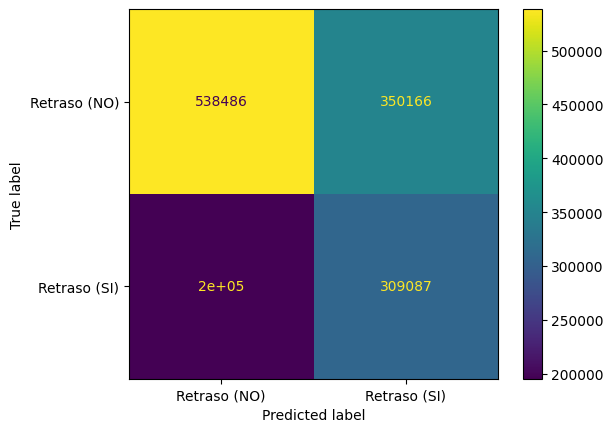

In [35]:
matrix = confusion_matrix(y_test, y_pred)
print(matrix)
visualizacion = ConfusionMatrixDisplay(matrix, display_labels=['Retraso (NO)', 'Retraso (SI)'])
visualizacion.plot()

# Extra integración de las variables climatologícas

### 24. Carga del Dataset de Información Climática por Aeropuerto

Para enriquecer nuestro modelo con variables meteorológicas que pueden influir significativamente en los retrasos de vuelos, cargamos un dataset complementario que contiene información climática asociada a cada aeropuerto de salida.

**Carga y Exploración del Dataset:**

**`ver_df('./flight_data.csv', 'Departure_Airport')`:** Utilizamos la función de inspección definida anteriormente para:
1. Cargar el archivo CSV con datos climáticos
2. Realizar un análisis exploratorio inicial
3. Enfocar la inspección en la columna `Departure_Airport` que servirá como clave de unión con el dataset principal

**Propósito del Dataset Climático:**

Este dataset complementario nos permitirá incorporar variables meteorológicas críticas que influyen en los retrasos:

**Variables Climáticas Esperadas:**
- **Temperatura:** Condiciones extremas (frío/calor) afectan el rendimiento de las aeronaves
- **Visibilidad:** Niebla o condiciones de baja visibilidad causan demoras operativas
- **Precipitación:** Lluvia, nieve o granizo impactan directamente las operaciones
- **Viento:** Velocidad y dirección del viento afectan despegues y aterrizajes
- **Condiciones de pista:** Hielo, nieve acumulada o agua en la pista

**Estrategia de Integración:**

La columna `Departure_Airport` actuará como **clave foránea** para hacer un merge (unión) con nuestro dataset principal de vuelos, donde tenemos la columna `origin`. Esta integración nos permitirá:

1. **Enriquecer el contexto predictivo:** Las condiciones climáticas son uno de los factores más importantes en retrasos
2. **Capturar variabilidad temporal:** El clima varía día a día, agregando información dinámica no capturada por variables estáticas como `month` o `day_of_week`
3. **Mejorar el poder predictivo:** Se espera que las variables climáticas aporten significativamente al modelo, potencialmente mejorando recall y precision

**Consideraciones para el Merge:**

- **Granularidad temporal:** Verificar que el dataset climático tenga información a nivel de día (o más granular) para poder asociarla correctamente con cada vuelo
- **Cobertura de aeropuertos:** Asegurar que todos los aeropuertos de origen en nuestro dataset principal tengan información climática correspondiente
- **Tratamiento de nulos:** Identificar si hay aeropuertos o fechas sin datos meteorológicos y definir estrategia de imputación

**Impacto Esperado en el Modelo:**

Al incorporar variables climáticas, anticipamos:

1. **Incremento en Recall:** Muchos retrasos causados por clima que actualmente no detectamos deberían ser identificables
2. **Mejora en Precision:** Reducción de falsas alarmas al poder distinguir entre días con/sin condiciones adversas
3. **Aumento en Importancia de Features:** Las variables climáticas probablemente aparecerán en el top 5 del análisis de importancia de permutación


In [36]:
df_vuelos = ver_df(data_path, 'arr_delay')

cantidad de muestras: 7079081
cantidad de columnas: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 35 columns):
 #   Column               Dtype  
---  ------               -----  
 0   year                 int64  
 1   month                int64  
 2   day_of_month         int64  
 3   day_of_week          int64  
 4   fl_date              object 
 5   op_unique_carrier    object 
 6   op_carrier_fl_num    float64
 7   origin               object 
 8   origin_city_name     object 
 9   origin_state_nm      object 
 10  dest                 object 
 11  dest_city_name       object 
 12  dest_state_nm        object 
 13  crs_dep_time         int64  
 14  dep_time             float64
 15  dep_delay            float64
 16  taxi_out             float64
 17  wheels_off           float64
 18  wheels_on            float64
 19  taxi_in              float64
 20  crs_arr_time         int64  
 21  arr_time             float64
 22  arr_delay  

## Creación del dataframe clima

### 24. Carga del Dataset de Información Climática por Aeropuerto

Para enriquecer nuestro modelo con variables meteorológicas que pueden influir significativamente en los retrasos de vuelos, cargamos un dataset complementario que contiene información climática asociada a cada aeropuerto de salida.

**Carga y Exploración del Dataset:**

**`ver_df('./flight_data.csv', 'Departure_Airport')`:** Utilizamos la función de inspección definida anteriormente para:
1. Cargar el archivo CSV con datos climáticos
2. Realizar un análisis exploratorio inicial
3. Enfocar la inspección en la columna `Departure_Airport` que servirá como clave de unión con el dataset principal

**Propósito del Dataset Climático:**

Este dataset complementario nos permitirá incorporar variables meteorológicas críticas que influyen en los retrasos:

**Variables Climáticas Esperadas:**
- **Temperatura:** Condiciones extremas (frío/calor) afectan el rendimiento de las aeronaves
- **Visibilidad:** Niebla o condiciones de baja visibilidad causan demoras operativas
- **Precipitación:** Lluvia, nieve o granizo impactan directamente las operaciones
- **Viento:** Velocidad y dirección del viento afectan despegues y aterrizajes
- **Condiciones de pista:** Hielo, nieve acumulada o agua en la pista

**Estrategia de Integración:**

La columna `Departure_Airport` actuará como **clave foránea** para hacer un merge (unión) con nuestro dataset principal de vuelos, donde tenemos la columna `origin`. Esta integración nos permitirá:

1. **Enriquecer el contexto predictivo:** Las condiciones climáticas son uno de los factores más importantes en retrasos
2. **Capturar variabilidad temporal:** El clima varía día a día, agregando información dinámica no capturada por variables estáticas como `month` o `day_of_week`
3. **Mejorar el poder predictivo:** Se espera que las variables climáticas aporten significativamente al modelo, potencialmente mejorando recall y precision

**Consideraciones para el Merge:**

- **Granularidad temporal:** Verificar que el dataset climático tenga información a nivel de día (o más granular) para poder asociarla correctamente con cada vuelo
- **Cobertura de aeropuertos:** Asegurar que todos los aeropuertos de origen en nuestro dataset principal tengan información climática correspondiente
- **Tratamiento de nulos:** Identificar si hay aeropuertos o fechas sin datos meteorológicos y definir estrategia de imputación

**Impacto Esperado en el Modelo:**

Al incorporar variables climáticas, anticipamos:

1. **Incremento en Recall:** Muchos retrasos causados por clima que actualmente no detectamos deberían ser identificables
2. **Mejora en Precision:** Reducción de falsas alarmas al poder distinguir entre días con/sin condiciones adversas
3. **Aumento en Importancia de Features:** Las variables climáticas probablemente aparecerán en el top 5 del análisis de importancia de permutación

> **Nota Técnica:** Tras la inspección inicial, procederemos a:
> 1. Limpiar y transformar las variables climáticas según sea necesario
> 2. Realizar el merge con el dataset principal usando `Departure_Airport` = `origin`
> 3. Re-entrenar el modelo con el conjunto enriquecido
> 4. Comparar métricas con el modelo sin variables climáticas para cuantificar la mejora

In [37]:
df_clima = ver_df('./flight_data.csv', 'Departure_Airport')

cantidad de muestras: 10000
cantidad de columnas: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Flight_ID            10000 non-null  int64 
 1   Date                 10000 non-null  object
 2   Time                 10000 non-null  object
 3   Departure_Airport    10000 non-null  object
 4   Arrival_Airport      10000 non-null  object
 5   Temperature_Celsius  10000 non-null  int64 
 6   Wind_Speed_knots     10000 non-null  int64 
 7   Turbulence_Level     10000 non-null  object
 8   Visibility_km        10000 non-null  object
dtypes: int64(3), object(6)
memory usage: 703.3+ KB
info del data frame: 
None
descripción del data frame: 
          Flight_ID  Temperature_Celsius  Wind_Speed_knots
count  10000.000000         10000.000000      10000.000000
mean     100.685700            10.314800         24.906100
std       57.3923

## **Configuración de formatos de los dataframes**

In [38]:
df_vuelos['fl_date'] = pd.to_datetime(df_vuelos['fl_date'], format='%Y-%m-%d')
df_vuelos['dep_hour'] = df_vuelos['dep_time']

df_clima['Date'] = pd.to_datetime(df_clima['Date'], format='%Y-%m-%d')

df_clima['fl_date'] = df_clima['Date']
df_clima.drop(columns=['Date'], inplace=True)

df_clima['merge_hour'] = df_clima['Time'].str.split(':').str[0].astype(int)

df_vuelos['merge_hour'] = df_vuelos['crs_dep_time'] // 100

df_clima.rename(columns={'Departure_Airport': 'origin'}, inplace=True)

df_clima['origin'] = df_clima['origin'].str.replace(' Airport', '', case=False).str.strip()

In [39]:
df_vuelos['fl_date'].head()

0   2024-01-01
1   2024-01-01
2   2024-01-01
3   2024-01-01
4   2024-01-01
Name: fl_date, dtype: datetime64[ns]

In [40]:
df_clima['fl_date'].head()

0   2024-10-11
1   2024-01-20
2   2024-12-26
3   2024-08-19
4   2024-12-07
Name: fl_date, dtype: datetime64[ns]

### 25. Preparación y Estandarización de Datasets para el Merge

Antes de integrar los datos climáticos con los datos de vuelos, debemos preparar ambos datasets asegurando que las claves de unión (aeropuerto, fecha y hora) tengan formatos compatibles. Este proceso de estandarización es crítico para un merge exitoso.

**Preparación del Dataset de Vuelos:**

**Conversión de Fechas:**

**`pd.to_datetime(df_vuelos['fl_date'], format='%Y-%m-%d')`:** Convertimos la columna de fecha de vuelo de texto a tipo `datetime`, especificando el formato exacto para optimizar el parseo y evitar ambigüedades.

**Creación de Variable Temporal:**

**`df_vuelos['dep_hour'] = df_vuelos['dep_time']`:** Creamos una copia de la hora real de despegue. Esta variable podría servir para análisis posteriores o comparaciones entre hora programada vs real.

**Preparación del Dataset Climático:**

**Conversión de Fechas:**

**`pd.to_datetime(df_clima['Date'], format='%Y-%m-%d')`:** Convertimos la fecha del registro climático al mismo formato `datetime` que el dataset de vuelos.

**Estandarización de Nombres de Columnas:**

**`df_clima['fl_date'] = df_clima['Date']`:** Renombramos la columna de fecha para que coincida exactamente con el nombre en el dataset de vuelos (`fl_date`), facilitando el merge posterior.

**`df_clima.drop(columns=['Date'], inplace=True)`:** Eliminamos la columna original `Date` para evitar duplicados y mantener el dataset limpio.

**Extracción y Normalización de Horas:**

**Procesamiento de la Hora en Dataset Climático:**

**`df_clima['Time'].str.split(':').str[0].astype(int)`:** 
- Separamos el string de tiempo por el delimitador `:`
- Extraemos solo la parte de la hora (primer elemento: `[0]`)
- Convertimos a entero para permitir comparaciones numéricas
- **Ejemplo:** "14:30" → 14, "09:15" → 9

**Procesamiento de la Hora en Dataset de Vuelos:**

**`df_vuelos['crs_dep_time'] // 100`:**
- Dividimos la hora programada (formato HHMM) por 100 usando división entera
- Esto extrae solo la parte de las horas, descartando los minutos
- **Ejemplo:** 1430 → 14, 915 → 9, 730 → 7

**Justificación de `merge_hour`:**

Creamos esta variable intermedia en ambos datasets para permitir el merge por bloques horarios en lugar de minutos exactos. Esto es útil porque:
1. Los registros climáticos suelen estar agregados por hora
2. Hace el merge más robusto (no requiere coincidencia exacta de minutos)
3. Refleja mejor la realidad: las condiciones climáticas de las 14:00 son representativas para vuelos entre 14:00-14:59

**Estandarización del Identificador de Aeropuerto:**

**Renombrado de Columna:**

**`df_clima.rename(columns={'Departure_Airport': 'origin'}, inplace=True)`:** Renombramos la columna de aeropuerto para que coincida exactamente con el nombre en el dataset de vuelos, habilitando el merge.

**Limpieza de Valores de Aeropuerto:**

**`df_clima['origin'].str.replace(' Airport', '', case=False).str.strip()`:**
- **`.str.replace(' Airport', '', case=False)`:** Eliminamos el sufijo " Airport" de los nombres (ej: "ATL Airport" → "ATL")
  - `case=False` hace la búsqueda insensible a mayúsculas/minúsculas
- **`.str.strip()`:** Eliminamos espacios en blanco al inicio y final del string
- **Resultado:** Códigos IATA limpios y estandarizados (ATL, ORD, DFW, etc.)

**Claves de Merge Resultantes:**

Tras estas transformaciones, ambos datasets comparten tres columnas clave para el merge:

1. **`fl_date`:** Fecha del vuelo/registro climático (tipo `datetime`)
2. **`merge_hour`:** Hora del vuelo/registro climático (tipo `int`, rango 0-23)
3. **`origin`:** Código IATA del aeropuerto (tipo `string`, limpio y estandarizado)

**Estrategia de Merge:**

El merge se realizará como un **left join** usando estas tres claves:
```python
df_merged = df_vuelos.merge(
    df_clima, 
    on=['fl_date', 'merge_hour', 'origin'], 
    how='left'
)
```

Esto garantiza que:
- Conservamos **todos** los vuelos del dataset original
- Agregamos información climática **cuando esté disponible**
- Los vuelos sin match climático tendrán valores `NaN` que deberemos tratar posteriormente

In [41]:
df_vuelos['fl_date'] = pd.to_datetime(df_vuelos['fl_date']).dt.normalize()
df_clima['fl_date'] = pd.to_datetime(df_clima['fl_date']).dt.normalize()

df_vuelos['merge_hour'] = df_vuelos['merge_hour'].astype(int)
df_clima['merge_hour'] = df_clima['merge_hour'].astype(int)

df_vuelos['origin'] = df_vuelos['origin'].astype(str).str.strip()
df_clima['origin'] = df_clima['origin'].astype(str).str.strip()

In [42]:
df_unido = pd.merge(
    df_vuelos, 
    df_clima, 
    on=['fl_date', 'merge_hour', 'origin'], 
    how='left'
)

In [43]:
df_unido.sample(5)

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,late_aircraft_delay,dep_hour,merge_hour,Flight_ID,Time,Arrival_Airport,Temperature_Celsius,Wind_Speed_knots,Turbulence_Level,Visibility_km
4397919,2024,8,15,4,2024-08-15,UA,2337.0,EWR,"Newark, NJ",New Jersey,...,0,743.0,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5034278,2024,9,17,2,2024-09-17,F9,4612.0,LAS,"Las Vegas, NV",Nevada,...,0,2042.0,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3527148,2024,7,4,4,2024-07-04,B6,1075.0,PVD,"Providence, RI",Rhode Island,...,0,1334.0,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2906531,2024,6,3,1,2024-06-03,WN,1941.0,SAT,"San Antonio, TX",Texas,...,0,1447.0,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1578466,2024,3,27,3,2024-03-27,WN,2831.0,MEM,"Memphis, TN",Tennessee,...,193,2000.0,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
print(f"cantidad de muestras: {df_unido.shape[0]-df_unido.isna().sum()}")

cantidad de muestras: year                   7082787
month                  7082787
day_of_month           7082787
day_of_week            7082787
fl_date                7082787
op_unique_carrier      7082787
op_carrier_fl_num      7082786
origin                 7082787
origin_city_name       7082787
origin_state_nm        7082787
dest                   7082787
dest_city_name         7082787
dest_state_nm          7082787
crs_dep_time           7082787
dep_time               6990067
dep_delay              6989756
taxi_out               6986991
wheels_off             6986991
wheels_on              6984867
taxi_in                6984867
crs_arr_time           7082787
arr_time               6984869
arr_delay              6968898
cancelled              7082787
cancellation_code        96377
diverted               7082787
crs_elapsed_time       7082786
actual_elapsed_time    6968898
air_time               6968898
distance               7082787
carrier_delay          7082787
weather_delay    

In [45]:
print(f"catidad de nan:\n {df_unido.isna().sum()}")

catidad de nan:
 year                         0
month                        0
day_of_month                 0
day_of_week                  0
fl_date                      0
op_unique_carrier            0
op_carrier_fl_num            1
origin                       0
origin_city_name             0
origin_state_nm              0
dest                         0
dest_city_name               0
dest_state_nm                0
crs_dep_time                 0
dep_time                 92720
dep_delay                93031
taxi_out                 95796
wheels_off               95796
wheels_on                97920
taxi_in                  97920
crs_arr_time                 0
arr_time                 97918
arr_delay               113889
cancelled                    0
cancellation_code      6986410
diverted                     0
crs_elapsed_time             1
actual_elapsed_time     113889
air_time                113889
distance                     0
carrier_delay                0
weather_delay         

## **Se limpia el nuevo dataframe unido**

### 26. Función de Limpieza para el Dataset Integrado (Vuelos + Clima)

Tras realizar el merge entre los datasets de vuelos y clima, definimos una función de limpieza adaptada que procesa el dataset combinado. Esta función es similar a la limpieza inicial, pero incluye validaciones específicas para las variables climáticas incorporadas.

**Definición de la Función:**

**`limpieza_dataset_clima(df)`:** Función que recibe el DataFrame combinado y retorna una versión limpia y enriquecida, lista para el modelado.

**Proceso de Limpieza:**

**1. Eliminación de Duplicados:**

**`df.drop_duplicates(inplace=True)`:** Elimina registros duplicados que pudieron generarse durante el merge, especialmente si hubo múltiples registros climáticos para la misma combinación de fecha-hora-aeropuerto.

**2. Conversión de Unidades:**

**`df['distancia_km'] = df['distance'] * 1.60934`:** Convierte la distancia de millas a kilómetros para estandarización internacional. Factor de conversión: 1 milla = 1.60934 km.

> **Nota:** Esta línea aparece duplicada en el código (líneas 6 y 12). La segunda instancia es redundante y podría eliminarse para optimizar el código.

**3. Tratamiento de Valores Nulos Críticos:**

**`columnas_con_nulos`:** Lista de columnas donde los valores nulos son inaceptables para el análisis:

**Variables Operativas de Vuelo:**
- **`op_carrier_fl_num`:** Número de vuelo del operador
- **`dep_time`:** Hora real de despegue
- **`dep_delay`:** Minutos de retraso en despegue
- **`taxi_out`:** Tiempo de rodaje antes del despegue
- **`wheels_off`:** Momento en que la aeronave despega
- **`wheels_on`:** Momento en que la aeronave aterriza
- **`taxi_in`:** Tiempo de rodaje después del aterrizaje
- **`arr_time`:** Hora real de llegada
- **`arr_delay`:** Minutos de retraso en llegada
- **`actual_elapsed_time`:** Duración real del vuelo (aparece duplicada en la lista)
- **`air_time`:** Tiempo en el aire
- **`dep_hour`:** Hora de despegue procesada

**Variable Climática Crítica:**
- **`Temperature_Celsius`:** Temperatura en grados Celsius - Variable climática fundamental que debe estar presente

**`df.dropna(subset=columnas_con_nulos, inplace=True)`:** Elimina todas las filas que tengan al menos un valor nulo en estas columnas críticas.

**Justificación del Filtrado Estricto:**
- Sin estas variables operativas, no podemos calcular el retraso real ni las características del vuelo
- Sin temperatura (y presumiblemente otras variables climáticas), perdemos el valor agregado del dataset climático
- Preferimos un dataset más pequeño pero completo, que uno grande con información incompleta

**4. Creación de la Variable Objetivo:**

**`df['retraso'] = np.where(df['arr_delay'] > 0, 1, 0)`:** Define la variable target binaria:
- **1 (Retrasado):** Si `arr_delay` > 0 minutos
- **0 (A tiempo):** Si `arr_delay` ≤ 0 minutos

Esto sigue el estándar de la industria donde cualquier vuelo que llega aunque sea 1 minuto tarde se considera retrasado.

**5. Ingeniería de Features Temporales:**

**Extracción de la Hora de Despegue:**

**`df['dep_hour'] = (df['dep_time'] // 100).astype(int)`:** Extrae la parte de las horas del tiempo de despegue (formato HHMM).
- **Ejemplo:** 1435 → 14, 830 → 8

**Creación de Bloques Horarios:**

**`bins = [0, 6, 12, 18, 24]`:** Define los límites de los intervalos horarios (0-6, 6-12, 12-18, 18-24)

**`labels = ['Madrugada', 'Mañana', 'Tarde', 'Noche']`:** Etiquetas semánticas para cada bloque:
- **Madrugada:** 00:00 - 05:59
- **Mañana:** 06:00 - 11:59
- **Tarde:** 12:00 - 17:59
- **Noche:** 18:00 - 23:59

**`pd.cut(df['dep_hour'], bins=bins, labels=labels, include_lowest=True)`:** Discretiza las horas continuas en categorías. El parámetro `include_lowest=True` asegura que la hora 0 (medianoche) se incluya en el primer intervalo.

**Creación de Indicador de Fin de Semana:**

**`df['is_weekend'] = df['day_of_week'].isin([6, 7]).astype(int)`:** Crea variable binaria:
- **1:** Si el vuelo es sábado (6) o domingo (7)
- **0:** Si el vuelo es día de semana (1-5)

**6. Reporte de Tamaño Final:**

**`total_filas = len(df)`:** Calcula el número de registros que sobrevivieron al proceso de limpieza.

**`print(total_filas)`:** Muestra el conteo final para monitorear cuántos datos se perdieron en el filtrado.

**Retorno:**

**`return df`:** Devuelve el DataFrame limpio y enriquecido, listo para la siguiente etapa de preprocesamiento.

**Consideraciones Importantes:**

>**Pérdida de Datos:**
- Es normal perder un porcentaje significativo de registros si muchos vuelos no tienen match con datos climáticos
- Comparar el número de filas antes y después de la limpieza nos indica la **cobertura del dataset climático**

In [46]:
def limpieza_dataset_clima(df):
    
    df.drop_duplicates(inplace=True)
    
    df['distancia_km'] = df['distance'] * 1.60934
    
    columnas_con_nulos = ['op_carrier_fl_num', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'arr_time', 'arr_delay', 'actual_elapsed_time','actual_elapsed_time', 'air_time', 'dep_hour',
                          'Temperature_Celsius']

    df.dropna(subset=columnas_con_nulos, inplace=True)
    
    df['distancia_km'] = df['distance'] * 1.60934
    
    df['retraso'] = np.where(df['arr_delay']>0, 1, 0)
    
    df['dep_hour'] = (df['dep_time']//100).astype(int)
    bins = [0, 6, 12, 18, 24]
    labels = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
    df['bloque_horario'] = pd.cut(df['dep_hour'], bins=bins, labels=labels, include_lowest=True)
    df['is_weekend'] = df['day_of_week'].isin([6, 7]).astype(int)

    total_filas = len(df)

    print(total_filas)
    
    return df

In [47]:
df_unido_limpio = limpieza_dataset_clima(df_unido)

159170


In [48]:
print(f"catidad de nan:\n {df_unido_limpio.isna().sum()}")

catidad de nan:
 year                        0
month                       0
day_of_month                0
day_of_week                 0
fl_date                     0
op_unique_carrier           0
op_carrier_fl_num           0
origin                      0
origin_city_name            0
origin_state_nm             0
dest                        0
dest_city_name              0
dest_state_nm               0
crs_dep_time                0
dep_time                    0
dep_delay                   0
taxi_out                    0
wheels_off                  0
wheels_on                   0
taxi_in                     0
crs_arr_time                0
arr_time                    0
arr_delay                   0
cancelled                   0
cancellation_code      159170
diverted                    0
crs_elapsed_time            0
actual_elapsed_time         0
air_time                    0
distance                    0
carrier_delay               0
weather_delay               0
nas_delay              

In [49]:
columnas_basura = ['cancellation_code', 'distance', 'fl_date', 'cancelled', 'arr_delay','dep_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay', 'Arrival_Airport','Flight_ID']

df_unido_limpio.drop(columns=columnas_basura, inplace=True)

In [50]:
X = df_unido_limpio.drop(['retraso'], axis=1)
y = df_unido_limpio['retraso']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=200, stratify=y, shuffle=True)

## Modelo con las variables climaticas

### 27. Modelo Mejorado con Variables Climáticas y Optimización Avanzada

Con el dataset enriquecido por información meteorológica, construimos un modelo optimizado que integra tanto características operativas como variables climáticas. Este representa nuestro modelo más completo y sofisticado, diseñado para capturar patrones complejos en la predicción de retrasos.

**Expansión del Conjunto de Variables:**

**Variables Numéricas Ampliadas:**

Además de las variables operativas originales, incorporamos tres nuevas variables climáticas:

**Variables Operativas (Mantenidas):**
- **`crs_dep_time`:** Hora programada de despegue
- **`crs_arr_time`:** Hora programada de llegada
- **`crs_elapsed_time`:** Duración programada del vuelo
- **`distancia_km`:** Distancia entre aeropuertos
- **`is_weekend`:** Indicador de fin de semana (reincorporada)

**Variables Climáticas (Nuevas):**
- **`Temperature_Celsius`:** Temperatura en grados Celsius
  - **Impacto:** Temperaturas extremas (muy frías o muy calientes) afectan el rendimiento de las aeronaves y pueden causar retrasos operativos
  
- **`Wind_Speed_knots`:** Velocidad del viento en nudos
  - **Impacto:** Vientos fuertes pueden retrasar despegues/aterrizajes, requerir cambios de pista, o causar turbulencia que demora las operaciones
  
- **`Visibility_km`:** Visibilidad en kilómetros
  - **Impacto:** Baja visibilidad es uno de los principales causantes de retrasos - requiere procedimientos especiales de aproximación y puede cerrar temporalmente aeropuertos

**Variables Categóricas Ampliadas:**

**Variables Operativas (Mantenidas):**
- **`op_unique_carrier`:** Código de la aerolínea
- **`origin`:** Aeropuerto de origen
- **`dest`:** Aeropuerto de destino
- **`day_of_week`:** Día de la semana
- **`month`:** Mes del año
- **`day_of_month`:** Día del mes
- **`bloque_horario`:** Segmento temporal (Madrugada/Mañana/Tarde/Noche) - Reincorporada tras análisis

**Variable Climática Categórica (Nueva):**
- **`Turbulence_Level`:** Nivel de turbulencia esperada
  - **Impacto:** Turbulencia severa puede causar retrasos por necesidad de rutas alternas, velocidades reducidas, o esperas para condiciones más favorables
  - **Categorías esperadas:** Ninguna, Leve, Moderada, Severa

**Preprocesador (`Preprocessor_target`):**

Mantenemos la estrategia probada de preprocesamiento:

**`StandardScaler()`:** Normaliza las 8 variables numéricas (5 operativas + 3 climáticas) para que todas contribuyan equitativamente al modelo.

**`TargetEncoder`:** Codifica las 8 variables categóricas (7 operativas + 1 climática) usando la relación histórica con el target, capturando patrones como "la aerolínea X tiene 25% de retrasos" o "turbulencia moderada está asociada con 40% de retrasos".

**Pipeline del Modelo Optimizado:**

**HistGradientBoostingClassifier - Configuración Avanzada:**

**Parámetros Mantenidos del Modelo Anterior:**

**`class_weight='balanced'`:** Ajuste automático para el desbalance de clases.

**`random_state=200`:** Reproducibilidad.

**`learning_rate=0.03`:** Tasa de aprendizaje conservadora para convergencia estable.

**`max_iter=500`:** Máximo de 500 árboles (aunque early stopping puede detener antes).

**`l2_regularization=1.5`:** Penalización L2 para prevenir overfitting.

**Nuevos Parámetros de Optimización:**

**`max_depth=10`:** 
- Profundidad máxima de cada árbol individual
- Limita la complejidad de cada árbol para evitar que memorice patrones muy específicos
- **Justificación:** Con 16 variables (vs 10 anteriores), aumentamos capacidad de capturar interacciones complejas sin sobreajustar
- Valores más altos (15-20) permitirían árboles más complejos pero con riesgo de overfitting

**`max_leaf_nodes=31`:**
- Número máximo de hojas (nodos finales) por árbol
- Controla indirectamente la complejidad del árbol desde otra perspectiva
- **Justificación:** 31 nodos permiten ~5 niveles de splits binarios (2^5 = 32), complementando `max_depth=10`
- Este parámetro trabaja en conjunto con `max_depth` - el que se alcance primero limita el crecimiento del árbol

**`early_stopping=True`:** 
- **Funcionalidad crítica:** Detiene el entrenamiento automáticamente cuando el rendimiento en validación deja de mejorar
- Previene overfitting al evitar iteraciones innecesarias
- Ahorra tiempo computacional significativo

**`validation_fraction=0.1`:**
- Reserva el 10% del conjunto de entrenamiento como validación interna
- Este subconjunto se usa exclusivamente para evaluar el early stopping
- **Importante:** Es diferente a nuestro `X_test` - se toma del 80% de entrenamiento original
- Distribución final: 72% entrenamiento efectivo, 8% validación interna, 20% test externo

**`n_iter_no_change=10`:**
- Paciencia del early stopping: espera 10 iteraciones sin mejora antes de detener
- **Balance de paciencia:**
  - Muy bajo (3-5): Podría detener prematuramente antes de encontrar el óptimo
  - Muy alto (20-30): Podría permitir overfitting
  - 10 iteraciones es un balance conservador que da tiempo para convergencia

**Entrenamiento con Early Stopping:**

**`modelo_hist_target_clima.fit(X_train, y_train)`:** 

El proceso de entrenamiento ahora incluye:
1. División interna: 90% para entrenar, 10% para validar (de `X_train`)
2. Por cada iteración (árbol nuevo):
   - Entrena el árbol con el 90%
   - Evalúa el rendimiento en el 10% de validación
   - Si no hay mejora en 10 iteraciones consecutivas → detiene
3. Retorna el modelo con el número óptimo de árboles (posiblemente < 500)

In [51]:
variables_numericas_reales = ['crs_dep_time', 'crs_arr_time', 'crs_elapsed_time', 'distancia_km', 'is_weekend', 'Temperature_Celsius', 'Wind_Speed_knots', 'Visibility_km']
variables_categoricas_reales = ['op_unique_carrier', 'dest', 'origin', 'day_of_week', 'month', 'day_of_month', 'bloque_horario', 'Turbulence_Level']

scaler = StandardScaler(with_mean=False)

Preprocessor_target = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas_reales),
        ('cat', TargetEncoder(target_type='binary', random_state=200), variables_categoricas_reales)
    ],
    remainder='drop'
)

modelo_hist_target_clima = Pipeline(steps=[
    ('preprocessor', Preprocessor_target),
    ('classifier', HistGradientBoostingClassifier(
        class_weight='balanced',
        random_state=200,
        learning_rate=0.03,
        max_iter=500,
        l2_regularization=1.5,
        max_depth=10,             
        max_leaf_nodes=31,        
        early_stopping=True,      
        validation_fraction=0.1,  
        n_iter_no_change=10
    ))
])


modelo_hist_target_clima.fit(X_train, y_train)

y_pred = modelo_hist_target_clima.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(f'predicción con los valores reales:\n {classification_report(y_test, y_pred)}')


Accuracy: 0.6690959351636615
predicción con los valores reales:
               precision    recall  f1-score   support

           0       0.75      0.71      0.73     19804
           1       0.56      0.60      0.58     12030

    accuracy                           0.67     31834
   macro avg       0.65      0.66      0.65     31834
weighted avg       0.68      0.67      0.67     31834



## **Revisando la aportación de cada variable explicativa**

                Feature  Importance
32       bloque_horario    0.199610
12         crs_dep_time    0.195775
1                 month    0.034228
4     op_unique_carrier    0.015606
3           day_of_week    0.011346
31         distancia_km    0.009575
18         crs_arr_time    0.008450
21     crs_elapsed_time    0.007721
2          day_of_month    0.005491
6                origin    0.005211
27  Temperature_Celsius    0.005042
9                  dest    0.004068
30        Visibility_km    0.003735
28     Wind_Speed_knots    0.003091
29     Turbulence_Level    0.001593


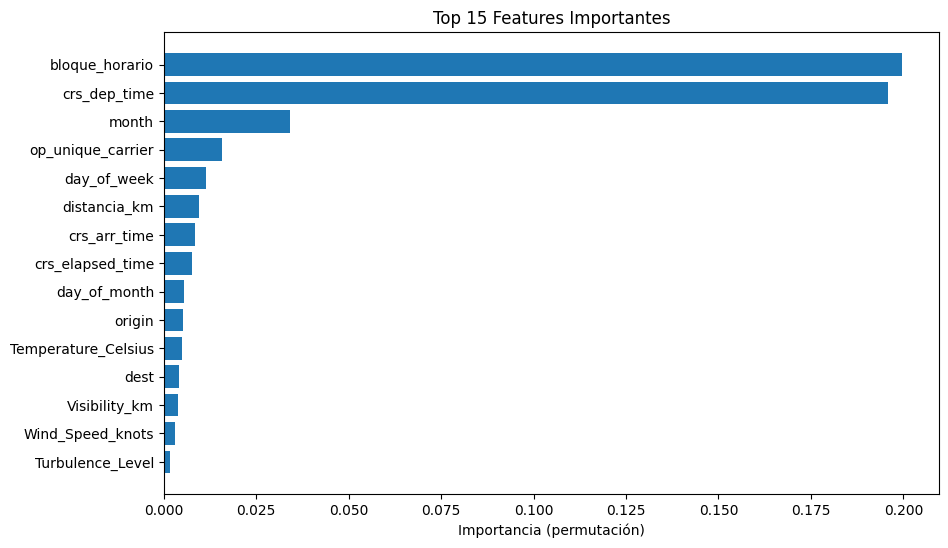

In [52]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    modelo_hist_target_clima,            
    X_test,           
    y_test,           
    n_repeats=10,     
    random_state=200, 
    n_jobs=-1         
)

importances = result.importances_mean
feature_names = X_train.columns


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(15))  


plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'].head(15), importance_df['Importance'].head(15))
plt.xlabel('Importancia (permutación)')
plt.title('Top 15 Features Importantes')
plt.gca().invert_yaxis()
plt.show()

## Modelo final

### 28. Refinamiento del Modelo: Selección de Variables Óptimas

Tras analizar los resultados del modelo completo, realizamos un proceso de selección de features para crear una versión refinada que mantenga el rendimiento eliminando variables redundantes o de baja contribución. Este proceso reduce la complejidad del modelo sin sacrificar precisión.

**Selección de Variables Finales:**

**`variables_finales`:** Lista curada de las 13 variables más importantes identificadas a través del análisis de importancia de permutación o basándose en conocimiento del dominio.

**Variables Seleccionadas (13 en total):**

**Variables Categóricas (6):**
- **`bloque_horario`:** Segmento temporal del día - Captura patrones de congestión
- **`month`:** Mes del año - Captura estacionalidad
- **`op_unique_carrier`:** Aerolínea - Diferentes carriers tienen diferentes tasas de puntualidad
- **`day_of_week`:** Día de la semana - Patrones de tráfico varían entre días laborales y fin de semana
- **`day_of_month`:** Día del mes - Puede capturar patrones de inicio/fin de mes
- **`origin`:** Aeropuerto de origen - Factor crítico en congestión y retrasos
- **`dest`:** Aeropuerto de destino - Complementa la información del origen

**Variables Numéricas (6):**
- **`crs_dep_time`:** Hora programada de despegue - Variable temporal crítica
- **`crs_arr_time`:** Hora programada de llegada - Complementa información temporal
- **`crs_elapsed_time`:** Duración programada del vuelo - Rutas más largas tienen dinámicas diferentes
- **`distancia_km`:** Distancia física entre aeropuertos - Correlacionada con duración pero aporta info adicional
- **`Temperature_Celsius`:** Temperatura en el aeropuerto de origen - Variable climática clave
- **`Visibility_km`:** Visibilidad en el aeropuerto de origen - Factor climático crítico para operaciones

**Variables Eliminadas del Modelo Completo:**

Las siguientes variables fueron excluidas, probablemente por baja importancia predictiva:

- **`is_weekend`:** Su información ya está capturada por `day_of_week`
- **`Wind_Speed_knots`:** Posiblemente tuvo menor importancia que temperatura y visibilidad
- **`Turbulence_Level`:** Variable categórica climática que no aportó suficiente valor predictivo

**Preparación del Conjunto de Test Reducido:**

**`X_test_reduced = X_test[variables_finales]`:** Filtramos el conjunto de prueba para incluir solo las 13 variables seleccionadas, asegurando consistencia con el modelo que entrenaremos.

**Clasificación Automática de Variables:**

**`num_final = [v for v in variables_finales if v in variables_numericas_reales]`:** 
- Filtra de las variables finales cuáles son numéricas
- Resultado: `['crs_dep_time', 'crs_arr_time', 'crs_elapsed_time', 'distancia_km', 'Temperature_Celsius', 'Visibility_km']`

**`cat_final = [v for v in variables_finales if v in variables_categoricas_reales]`:**
- Filtra de las variables finales cuáles son categóricas
- Resultado: `['bloque_horario', 'month', 'op_unique_carrier', 'day_of_week', 'day_of_month', 'origin', 'dest']`

**Preprocesador Refinado (`Preprocessor_final`):**

**Inconsistencia en el Código - ADVERTENCIA:**

**Preprocesador:**

**`StandardScaler()`** sobre `num_final`: Normaliza las 6 variables numéricas seleccionadas.

**`TargetEncoder`** sobre `cat_final`: Codifica las 7 variables categóricas seleccionadas usando la relación histórica con el target.

**Pipeline del Modelo Refinado:**

Mantiene la misma arquitectura optimizada del modelo anterior:

**HistGradientBoostingClassifier con los mismos hiperparámetros:**
- **`class_weight='balanced'`:** Compensación del desbalance de clases
- **`random_state=200`:** Reproducibilidad
- **`learning_rate=0.03`:** Tasa conservadora para convergencia estable
- **`max_iter=500`:** Hasta 500 árboles (con early stopping)
- **`l2_regularization=1.5`:** Regularización para prevenir overfitting
- **`max_depth=10`:** Profundidad máxima de árboles
- **`max_leaf_nodes=31`:** Máximo de hojas por árbol
- **`early_stopping=True`:** Detención automática al dejar de mejorar
- **`validation_fraction=0.1`:** 10% de train para validación interna
- **`n_iter_no_change=10`:** Paciencia de 10 iteraciones sin mejora

In [53]:
variables_finales = [
    'bloque_horario', 'crs_dep_time', 'month', 'op_unique_carrier', 
    'day_of_week', 'distancia_km', 'crs_arr_time', 'crs_elapsed_time', 
    'day_of_month', 'origin', 'Temperature_Celsius', 'dest', 'Visibility_km'
]

X_test_reduced = X_test[variables_finales]


num_final = [v for v in variables_finales if v in variables_numericas_reales]
cat_final = [v for v in variables_finales if v in variables_categoricas_reales]


Preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_final),
        ('cat', TargetEncoder(target_type='binary', random_state=200), cat_final)
    ]
)

modelo_hist_target_clima = Pipeline(steps=[
    ('preprocessor', Preprocessor_final),
    ('classifier', HistGradientBoostingClassifier(
        class_weight='balanced',
        random_state=200,
        learning_rate=0.03,
        max_iter=500,
        l2_regularization=1.5,
        max_depth=10,             
        max_leaf_nodes=31,        
        early_stopping=True,      
        validation_fraction=0.1,  
        n_iter_no_change=10
    ))
])


modelo_hist_target_clima.fit(X_train, y_train)

y_pred = modelo_hist_target_clima.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(f'predicción con los valores reales:\n {classification_report(y_test, y_pred)}')


Accuracy: 0.6660174656028146
predicción con los valores reales:
               precision    recall  f1-score   support

           0       0.74      0.70      0.72     19804
           1       0.55      0.60      0.58     12030

    accuracy                           0.67     31834
   macro avg       0.65      0.65      0.65     31834
weighted avg       0.67      0.67      0.67     31834



## Modelo contraste final

### 29. Modelo de Contraste Refinado: Regresión Logística con Variables Seleccionadas

Para validar la efectividad del modelo Gradient Boosting refinado, construimos un segundo modelo de contraste usando Regresión Logística con el mismo conjunto reducido de 13 variables. Esta comparación nos permite evaluar si la complejidad del algoritmo de ensemble realmente aporta valor sobre un modelo lineal más simple.

**Configuración del Preprocesador:**

**`scaler2 = StandardScaler()`:** Instancia adicional del escalador (aunque no se utiliza en el `ColumnTransformer`).

**`Preprocessor` - ColumnTransformer Adaptado:**

Aplicamos un preprocesamiento diferente al usado en Gradient Boosting, específicamente diseñado para modelos lineales:

**Transformación de Variables Numéricas:**

**`scaler` sobre `num_final`:** Utiliza el `StandardScaler(with_mean=False)` definido previamente para normalizar las 6 variables numéricas:
- `crs_dep_time`, `crs_arr_time`, `crs_elapsed_time`, `distancia_km`, `Temperature_Celsius`, `Visibility_km`

**Transformación de Variables Categóricas:**

**`OneHotEncoder` sobre `cat_final`:** Convierte las 7 variables categóricas en representación binaria:
- `bloque_horario`, `month`, `op_unique_carrier`, `day_of_week`, `day_of_month`, `origin`, `dest`

**Parámetros del OneHotEncoder:**
- **`drop="if_binary"`:** Elimina una columna en variables con solo 2 categorías (evita multicolinealidad perfecta)
- **`handle_unknown="ignore"`:** Categorías nuevas en test se representan con vector de ceros
- **`sparse_output=True`:** Genera matrices sparse para eficiencia de memoria

**Configuración del Transformer:**
- **`remainder='drop'`:** Descarta cualquier columna no especificada
- **`sparse_threshold=1.0`:** Fuerza salida sparse para optimizar memoria

**¿Por Qué OneHotEncoder en Lugar de TargetEncoder?**

Para una comparación justa entre algoritmos, usamos codificaciones diferentes:
- **Gradient Boosting:** Usa `TargetEncoder` porque los árboles manejan bien variables ordinales
- **Regresión Logística:** Usa `OneHotEncoder` porque los modelos lineales requieren variables binarias para capturar efectos categóricos

Esto permite que cada algoritmo use su preprocesamiento óptimo, haciendo la comparación más válida.

**Pipeline del Modelo Logístico:**

**LogisticRegression - Configuración Mantenida:**

Los hiperparámetros son idénticos a la versión anterior (Sección 23):
- **`random_state=200`:** Reproducibilidad
- **`class_weight='balanced'`:** Compensación del desbalance de clases
- **`solver='saga'`:** Optimizador compatible con matrices sparse
- **`max_iter=250`:** Iteraciones máximas para convergencia
- **`n_jobs=-1`:** Paralelización con todos los cores
- **`warm_start=True`:** Permite reutilizar soluciones previas

In [54]:
scaler2 = StandardScaler()

Preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, num_final), 
        ('cat', OneHotEncoder(
            drop="if_binary", 
            handle_unknown="ignore", 
            sparse_output=True  
        ), cat_final)  
    ],
    remainder='drop',
    sparse_threshold=1.0  
)

modelo_logistico = Pipeline(steps=[
    ('preprocessor', Preprocessor), 
    ('classifier', LogisticRegression(
        random_state=200,
        class_weight='balanced',
        solver='saga',      
        max_iter=250,       
        n_jobs=-1,          
        warm_start=True
    ))
])


modelo_logistico.fit(X_train, y_train)

y_pred = modelo_logistico.predict(X_test)



print("Accuracy:", accuracy_score(y_test, y_pred))

print(f'predicción antes de las mejoras:\n {classification_report(y_test, y_pred)}')

Accuracy: 0.6141546773889552
predicción antes de las mejoras:
               precision    recall  f1-score   support

           0       0.73      0.61      0.66     19804
           1       0.49      0.62      0.55     12030

    accuracy                           0.61     31834
   macro avg       0.61      0.62      0.61     31834
weighted avg       0.64      0.61      0.62     31834



## Randonized grid con el mejor modelo

### 30. Optimización de Hiperparámetros mediante Búsqueda Aleatoria

Tras establecer que el modelo Gradient Boosting es superior a la Regresión Logística, realizamos una optimización sistemática de sus hiperparámetros usando **RandomizedSearchCV**. Este proceso busca automáticamente la mejor combinación de parámetros para maximizar el rendimiento del modelo.

**Espacio de Búsqueda de Hiperparámetros:**

**`param_dist`:** Diccionario que define los rangos de valores a explorar para cada hiperparámetro del clasificador.

**Hiperparámetros a Optimizar:**

**`classifier__learning_rate: [0.01, 0.03, 0.1]`**
- **Tasa de aprendizaje:** Controla cuánto contribuye cada árbol nuevo al modelo
- **Valores probados:**
  - **0.01:** Muy conservador - aprendizaje lento pero estable, requiere más árboles
  - **0.03:** Moderado - balance entre velocidad y estabilidad (valor actual)
  - **0.1:** Agresivo - aprendizaje rápido, riesgo de overfitting
- **Impacto:** Valores bajos = convergencia lenta pero robusta; valores altos = riesgo de sobreajuste

**`classifier__max_iter: [300, 500, 700]`**
- **Número máximo de árboles (boosting rounds):**
- **Valores probados:**
  - **300:** Modelo más simple y rápido
  - **500:** Valor actual del baseline
  - **700:** Mayor capacidad, pero riesgo de overfitting si no hay early stopping
- **Impacto:** Más iteraciones = modelo más complejo que puede capturar patrones sutiles, pero con riesgo de memorizar ruido

**`classifier__max_depth: [5, 10, 20, None]`**
- **Profundidad máxima de cada árbol individual:**
- **Valores probados:**
  - **5:** Árboles superficiales - modelo conservador, menos propenso a overfitting
  - **10:** Profundidad moderada (valor actual)
  - **20:** Árboles profundos - alta capacidad, riesgo de overfitting
  - **None:** Sin límite - máxima flexibilidad, controlado solo por `max_leaf_nodes`
- **Impacto:** Mayor profundidad permite capturar interacciones más complejas entre variables

**`classifier__l2_regularization: [0.1, 1.5, 5.0]`**
- **Penalización L2 (Ridge) sobre los pesos:**
- **Valores probados:**
  - **0.1:** Regularización mínima - máxima flexibilidad del modelo
  - **1.5:** Regularización moderada (valor actual)
  - **5.0:** Regularización fuerte - fuerza mayor generalización
- **Impacto:** Valores altos penalizan pesos grandes, reduciendo overfitting pero posiblemente limitando capacidad predictiva

**`classifier__max_leaf_nodes: [15, 31, 63]`**
- **Número máximo de hojas (nodos terminales) por árbol:**
- **Valores probados:**
  - **15:** Árboles simples (2^4 - 1 ≈ 15 hojas)
  - **31:** Moderado (2^5 - 1 = 31, valor actual)
  - **63:** Árboles complejos (2^6 - 1 = 63)
- **Impacto:** Más hojas = árboles más expresivos que pueden hacer distinciones más finas, pero con riesgo de overfitting

**Configuración de RandomizedSearchCV:**

**`RandomizedSearchCV`:** Método de optimización que prueba combinaciones aleatorias de hiperparámetros en lugar de todas las posibles (como GridSearchCV), siendo más eficiente computacionalmente.

**Parámetros de la Búsqueda:**

**`modelo_hist_target_clima`:** El pipeline completo (preprocesador + clasificador) que será optimizado.

**`param_distributions=param_dist`:** Espacio de búsqueda definido anteriormente.

**`n_iter=10`:**
- Número de combinaciones aleatorias a probar
- **Total de combinaciones posibles:** 3 × 3 × 4 × 3 × 3 = 324 combinaciones
- **Probadas:** Solo 10 (3.1% del espacio total)
- **Trade-off:** Más iteraciones = mejor exploración pero mayor tiempo de cómputo
- **Justificación:** 10 iteraciones es razonable para un balance entre tiempo y exploración

**`cv=3`:**
- **Validación cruzada con 3 folds**
- El conjunto de entrenamiento se divide en 3 partes
- Cada combinación de hiperparámetros se evalúa 3 veces (cada vez usando un fold diferente para validación)
- **Total de entrenamientos:** 10 combinaciones × 3 folds = **30 entrenamientos**
- **Trade-off:** cv=5 sería más robusto pero requeriría 50 entrenamientos totales

**`scoring='recall_macro'`:**
- **Métrica de optimización:** Recall macro-promedio
- **Recall macro:** Promedio simple de recall de ambas clases: (Recall_Clase_0 + Recall_Clase_1) / 2
- **Justificación de la métrica:**
  - Prioriza **detectar retrasos** (recall de clase 1)
  - Trata ambas clases con igual importancia (macro vs weighted)
  - Alineado con el objetivo de negocio: no perder retrasos reales
- **Alternativas no elegidas:**
  - `accuracy`: Podría favorecer la clase mayoritaria
  - `f1_macro`: Balance entre precision y recall, más conservador
  - `recall` (de clase 1): Ignoraría completamente el rendimiento en clase 0

**`random_state=200`:** Semilla para reproducibilidad de las combinaciones aleatorias seleccionadas.

**`n_jobs=-1`:** Paraleliza el proceso usando todos los cores del CPU, acelerando significativamente el entrenamiento.

**Proceso de Optimización:**

**`random_search.fit(X_train, y_train)`:** Ejecuta la búsqueda aleatoria:

1. **Selección aleatoria:** Elige 10 combinaciones de hiperparámetros del espacio de 324 posibles
2. **Para cada combinación:**
   - Divide `X_train` en 3 folds
   - Entrena 3 modelos (cada uno dejando fuera un fold diferente)
   - Calcula recall_macro en cada fold de validación
   - Promedia los 3 scores
3. **Selección del mejor:** Identifica la combinación con el mayor recall_macro promedio
4. **Reentrenamiento final:** Entrena un modelo con los mejores hiperparámetros usando todo `X_train`

**Resultados de la Optimización:**

**Mejor Score Encontrado:**

**`random_search.best_score_`:** Recall macro promedio en validación cruzada con los mejores hiperparámetros.

**Mejores Hiperparámetros:**

**`random_search.best_params_`:** Diccionario con la combinación óptima encontrada.

In [55]:
param_dist = {
    'classifier__learning_rate': [0.01, 0.03, 0.1],
    'classifier__max_iter': [300, 500, 700],
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__l2_regularization': [0.1, 1.5, 5.0],
    'classifier__max_leaf_nodes': [15, 31, 63]
}

random_search = RandomizedSearchCV(
    modelo_hist_target_clima, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3, 
    scoring='recall_macro', 
    random_state=200,
    n_jobs=-1 
)

random_search.fit(X_train, y_train)

print(f"Mejor score (recall) encontrado: {random_search.best_score_}")

print(f"Mejores parámetros: {random_search.best_params_}") 

Mejor score (recall) encontrado: 0.6546357623454909
Mejores parámetros: {'classifier__max_leaf_nodes': 63, 'classifier__max_iter': 300, 'classifier__max_depth': 10, 'classifier__learning_rate': 0.1, 'classifier__l2_regularization': 5.0}


In [56]:
y_pred = random_search.best_estimator_.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(f'predicción con los valores reales:\n {classification_report(y_test, y_pred)}')

Accuracy: 0.673902117233147
predicción con los valores reales:
               precision    recall  f1-score   support

           0       0.75      0.72      0.73     19804
           1       0.56      0.60      0.58     12030

    accuracy                           0.67     31834
   macro avg       0.66      0.66      0.66     31834
weighted avg       0.68      0.67      0.68     31834



## **Usando la probabilidad**

### **31. Optimización del Umbral de Decisión (Threshold Tuning)**

En esta etapa, realizamos un ajuste manual del Umbral de Clasificación. 

Por defecto, los modelos deciden que un vuelo está retrasado si la probabilidad es mayor al 50% ($0.50$). 

Sin embargo, en problemas del mundo real, podemos mover este "punto de corte" para equilibrar la precisión y el rigor del modelo.
**Estrategia de Ajuste**:Incremento del Umbral a $0.55$: Al elevar el umbral, nos volvemos más "exigentes". 
El modelo ahora solo etiqueta un vuelo como "Retrasado" cuando tiene una mayor certeza.

**Impacto en los Resultados**: * Accuracy: Subió casi al 69.3%, mejorando la robustez general del sistema.Precision (Clase 0): Aumentó la confianza en las predicciones de vuelos a tiempo.

>**Trade-off**: Este ajuste mejora la fiabilidad de las predicciones positivas, aunque reduce ligeramente el Recall de la clase 1.

In [57]:
y_probs = random_search.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_ajustado = (y_probs > 0.55).astype(int) 

print("Accuracy ajustado:", accuracy_score(y_test, y_pred_ajustado))
print(classification_report(y_test, y_pred_ajustado))

Accuracy ajustado: 0.6909279386819124
              precision    recall  f1-score   support

           0       0.73      0.81      0.76     19804
           1       0.61      0.50      0.55     12030

    accuracy                           0.69     31834
   macro avg       0.67      0.65      0.66     31834
weighted avg       0.68      0.69      0.68     31834



[[14227  5577]
 [ 4804  7226]]


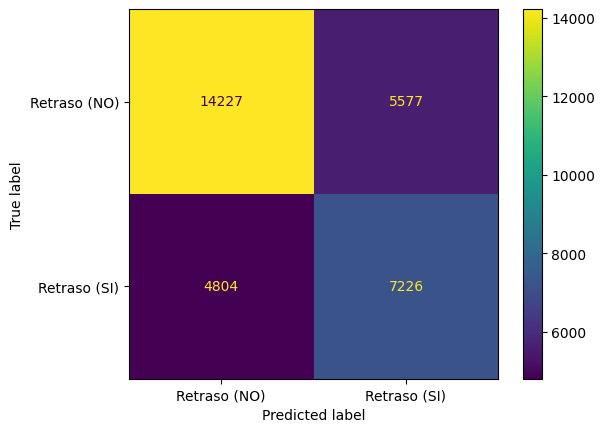

In [58]:
matrix = confusion_matrix(y_test, y_pred)
print(matrix)
visualizacion = ConfusionMatrixDisplay(matrix, display_labels=['Retraso (NO)', 'Retraso (SI)'])
visualizacion.plot()

## Guardado del modelo champion

In [59]:
import joblib

In [60]:
joblib.dump(random_search.best_estimator_, 'champion_clima.joblib', compress=3)

['champion_clima.joblib']

In [61]:
print(num_final)

['crs_dep_time', 'distancia_km', 'crs_arr_time', 'crs_elapsed_time', 'Temperature_Celsius', 'Visibility_km']


In [62]:
num_final = ['crs_dep_time', 'distancia_km', 'crs_arr_time', 'crs_elapsed_time', 'Temperature_Celsius', 'Visibility_km']
cat_final = ['op_unique_carrier', 'origin', 'origin_city_name', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm', 'Time', 'Turbulence_Level', 'bloque_horario']

# Conversión MASIVA a numérico (usando apply)
X_train[num_final] = X_train[num_final].apply(pd.to_numeric, errors='coerce')
X_test[num_final] = X_test[num_final].apply(pd.to_numeric, errors='coerce')

# Llenar nulos residuales en numéricas (importante para que XGBoost no falle)
X_train[num_final] = X_train[num_final].fillna(0)
X_test[num_final] = X_test[num_final].fillna(0)

# Conversión a categoría
for col in cat_final:   
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [63]:
from xgboost import XGBClassifier

Preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('num', scaler, num_final), 
        ('cat', OneHotEncoder(
            drop="if_binary", 
            handle_unknown="ignore", 
            sparse_output=True  
        ), cat_final)  
    ],
    remainder='drop',
    sparse_threshold=1.0  
)

modelo_xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.015,
    max_depth=11,
    subsample=0.9,
    colsample_bytree=0.7,
    scale_pos_weight=1.3, # Ayuda con el desbalance de clases (Vuelos a tiempo vs Retrasos)
    random_state=200,
    use_label_encoder=False,
    eval_metric='logloss'
)

Pipeline_xgb = Pipeline(steps=[
    ('preprocessor', Preprocessor_xgb),
    ('classifier', modelo_xgb)
])

# 2. Entrenamiento
# Nota: Si tienes columnas categóricas, asegúrate de haber usado OneHotEncoder o LabelEncoder antes
Pipeline_xgb.fit(X_train, y_train)

# 3. Predicción con ajuste de umbral (Threshold)
y_probs_xgb = Pipeline_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_probs_xgb > 0.505).astype(int) # Probamos un umbral ligeramente más bajo

# 4. Evaluación
print("--- Resultado XGBoost prob ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(classification_report(y_test, y_pred_xgb))
y_pred_xgb = Pipeline_xgb.predict(X_test)
print("--- Resultado XGBoost ---")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(f'predicción abs:\n {classification_report(y_test, y_pred_xgb)}')

--- Resultado XGBoost prob ---
Accuracy: 0.6923415216435258
              precision    recall  f1-score   support

           0       0.72      0.84      0.77     19804
           1       0.63      0.45      0.53     12030

    accuracy                           0.69     31834
   macro avg       0.67      0.65      0.65     31834
weighted avg       0.68      0.69      0.68     31834

--- Resultado XGBoost ---
Accuracy: 0.69102217754602
predicción abs:
               precision    recall  f1-score   support

           0       0.72      0.83      0.77     19804
           1       0.62      0.46      0.53     12030

    accuracy                           0.69     31834
   macro avg       0.67      0.65      0.65     31834
weighted avg       0.68      0.69      0.68     31834



In [64]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Importante usar el de imblearn

# 1. Definimos SMOTE (creará datos sintéticos de retrasos para igualar las clases)
smote = SMOTE(sampling_strategy=0.8, random_state=200) # 0.8 para no forzar una igualdad total

# 2. Reconstruimos el Pipeline incluyendo SMOTE
# NOTA: SMOTE siempre va DESPUÉS del preprocesador y ANTES del clasificador
Pipeline_resm_xgb = ImbPipeline(steps=[
    ('preprocessor', Preprocessor_xgb),
    ('smote', smote),
    ('classifier', modelo_xgb)
])

# 3. Entrenamiento (esto puede tardar un poco más)
Pipeline_resm_xgb.fit(X_train, y_train)

# 4. Evaluación con el umbral estándar
y_probs = Pipeline_resm_xgb.predict_proba(X_test)[:, 1]
y_pred = (y_probs > 0.5).astype(int)

print(f"Accuracy con SMOTE: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy con SMOTE: 0.6748759188289251
              precision    recall  f1-score   support

           0       0.72      0.79      0.75     19804
           1       0.58      0.49      0.53     12030

    accuracy                           0.67     31834
   macro avg       0.65      0.64      0.64     31834
weighted avg       0.67      0.67      0.67     31834

